<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Value Based</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


| Student Name | Student ID | Email |
| :--- | :--- | :--- |
| **Mehmet Karaca** | 20250344 | 20250344@novaims.unl.pt |
| **Duarte Gomes** | 20250017 | 20250017@novaims.unl.pt |
| **Esra Salhi** | 20250537 | 20250537@novaims.unl.pt |

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [1]:
# Imports
import os
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as Line2D
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
from cycler import cycler
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.base import clone
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from minisom import MiniSom

from sklearn.metrics import silhouette_score, davies_bouldin_score
from collections import Counter



In [2]:
import warnings

# Suppress FutureWarnings (covers the pandas 3.0 CoW warnings)
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [3]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_FlightsDB_Cleaned_Featured.csv', 'DM_AIAI_CustomerDB_Cleaned_Featured.csv']


In [4]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 53)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [5]:
# Put Loyalty# as index
customers.set_index('Loyalty#', inplace=True)
customers.columns


Index(['First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Gender_male', 'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Marital Status_Married', 'Marital Status_Single',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick',

In [6]:
customers.describe(include='number')

,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,...,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban
count,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,16375.000000,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,...,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,-3.888350e-15,2.681621e-16,-1.388542e-17,8.331249e-17,0.874931,-1.238839e-16,9.633007e-17,-1.598992e-16,-1.863683e-16,2.625211e-17,...,0.037924,0.015084,0.032122,0.322870,0.004031,0.196153,0.023878,0.006473,0.339053,0.326168
std,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,0.330807,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,...,0.191018,0.121891,0.176330,0.467588,0.063360,0.397098,0.152673,0.080198,0.473402,0.468824
min,-1.266925e+00,-1.942818e+00,-1.243243e+00,-8.893668e-01,0.000000,-1.489489e+00,-2.348401e+00,-1.532043e+00,-1.786988e+00,-1.786934e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.900536e-01,-1.276641e+00,-1.243243e+00,-5.851120e-01,1.000000,-9.714138e-01,-5.664426e-01,-8.118356e-01,-8.402688e-01,-8.403008e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-3.285937e-01,5.599171e-01,-1.188661e-01,-3.217508e-01,1.000000,-9.716237e-02,1.911105e-01,4.341034e-02,2.687935e-01,2.688672e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.375646e-01,7.751104e-01,8.125391e-01,1.395840e-01,1.000000,8.769265e-01,7.854892e-01,7.186045e-01,7.650067e-01,7.650795e-01,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,4.096615e+00,1.758859e+00,2.051974e+00,1.101364e+01,1.000000,1.837524e+00,2.644027e+00,3.824498e+00,2.605733e+00,2.605996e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 2. Clustering

For the Clustering we will look at the value based and demographic perspective

In [7]:
# Cell 3: Helper functions from Labs 09-12

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns:
    float: The between-group sum of squares of the DataFrame.
    """
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))))
    
    ssb = np.sum(ssb_i)
    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)


def get_r2_scores(df, feats, clusterer, min_k=2, max_k=11):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

In [8]:
# Cell 5: Define feature perspectives

# demographic features selection (only categorical features encoded as dummies)
demographic_features = [
    'Location Code_Suburban',
    'Location Code_Urban',
    'Gender_male',
    'Education_College',
    'Education_High School or Below',
    'Education_Master',
    'Education_Doctor',
    'Marital Status_Married',
    'Marital Status_Single',
]

# Value based features selection
value_based_features = [
    'Customer Lifetime Value',
    'Income',
    'total_points_accumulated',
    'total_cost_redeemed']

# Combined metric features (for final analysis)
metric_features = demographic_features + value_based_features

print("Demographic features:", demographic_features)
print("Value based features:", value_based_features)
print("Total metric features:", len(metric_features))


Demographic features: ['Location Code_Suburban', 'Location Code_Urban', 'Gender_male', 'Education_College', 'Education_High School or Below', 'Education_Master', 'Education_Doctor', 'Marital Status_Married', 'Marital Status_Single']
Value based features: ['Customer Lifetime Value', 'Income', 'total_points_accumulated', 'total_cost_redeemed']
Total metric features: 13


## 2.1 Value based Clustering

In this Section we prepare our data for Value Based Clustering.
We have to decide, which features we will use for Clustering from Value Based Perspective.
We selected the features based on domain knowledge and our understanding of the business.
We will use the following features for Clustering from Value Based Perspective:

In [9]:
# Show the selected featurescustomers[preference_features].head()
customers[value_based_features].head()

# Print number of metric features   
print ("Number of metric features:", len(value_based_features))

# check if metric or not 

for feature in value_based_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")


# Create the pandas dataframe df_value_based
df_value_based = pd.DataFrame(customers[value_based_features])

df_value_based.head()

Number of metric features: 4
Customer Lifetime Value: Metric
Income: Metric
total_points_accumulated: Metric
total_cost_redeemed: Metric


,Customer Lifetime Value,Income,total_points_accumulated,total_cost_redeemed
Loyalty#,,,,
480934,-0.605614,1.068659,1.338311,0.576033
549612,-0.605545,-1.243243,0.843514,1.584071
429460,-0.605524,-1.243243,-0.317841,-0.369294
608370,-0.605524,-1.243243,0.592203,0.896561
530508,-0.605080,1.981146,0.488700,-0.987124


Before starting with the first Clustering Method, we will remove highly correlated features from the dataset. Highly correlated features can negatively impact the performance of clustering algorithms (e.g., KMeans). We will use a correlation threshold of 0.8 to identify and remove highly correlated features.

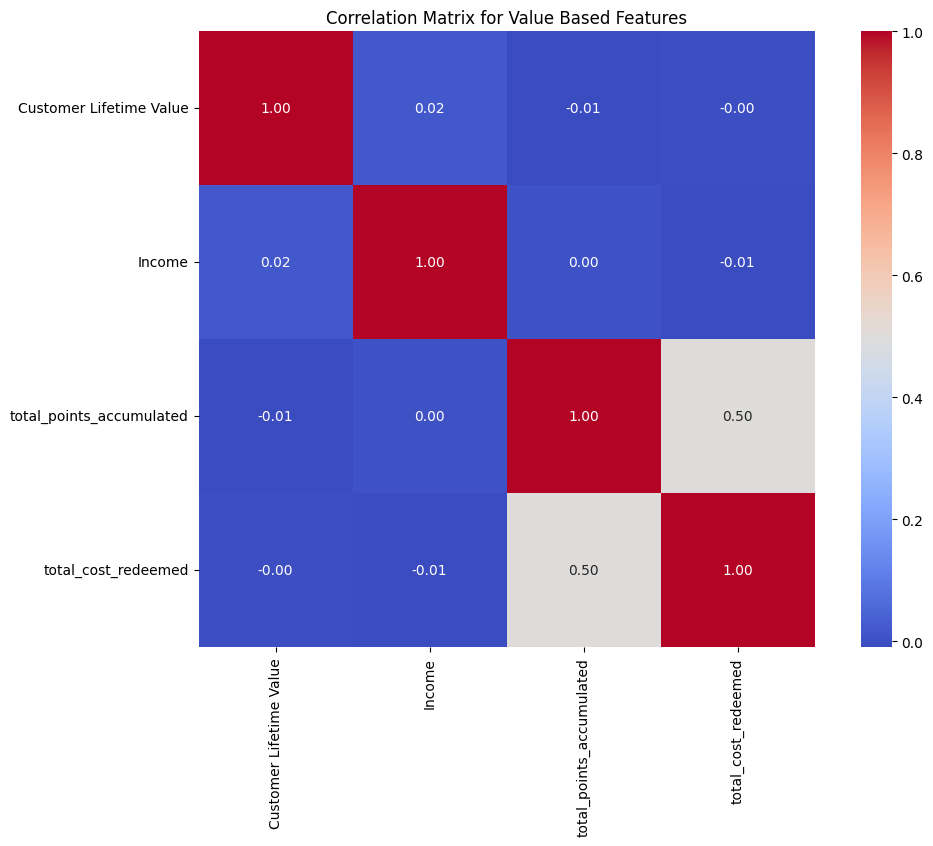

Pairs with correlation > 0.8 or < -0.8:
Series([], dtype: float64)


In [10]:
# Check for correlation inside the value based features
plt.figure(figsize=(12, 8))
correlation_matrix = df_value_based.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Value Based Features")
plt.show()

threshold = 0.8
unstacked = correlation_matrix.unstack()
high_corr = unstacked[(unstacked.abs() > threshold) & (unstacked != 1.0)].drop_duplicates()

print(f"Pairs with correlation > {threshold} or < -{threshold}:")
print(high_corr)

We will do K-Means++ Clustering and compare it with Hierarchical Clustering

In [11]:
# --- Comprehensive Clustering Evaluation with All Metrics ---

def evaluate_clustering_methods(data, feats, min_k=2, max_k=11):
    """
    Evaluates multiple clustering methods and calculates:
    - R2 Score
    - Davies-Bouldin Index (DBI)
    - Silhouette Score
    - Inertia (for KMeans-based methods)
    
    Returns a dictionary with DataFrames for each method.
    """
    
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Total Sum of Squares (SST) once for R2 calculation
    centroid = X.mean(axis=0)
    sst = np.sum((X - centroid) ** 2)
    
    # Initialize results dictionary
    results_by_method = {}
    
    # --- K-MEANS ---
    print("Evaluating K-Means...")
    kmeans_results = []
    kmeans_clusterer = KMeans(init='k-means++', n_init=20, random_state=42)
    
    for k in range(min_k, max_k):
        kmeans = clone(kmeans_clusterer).set_params(n_clusters=k)
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        ssw = kmeans.inertia_
        r2 = 1 - (ssw / sst)
        dbi = davies_bouldin_score(X, labels)
        sil = silhouette_score(X, labels)
        
        kmeans_results.append({
            'K': k,
            'R2_Score': r2,
            'Davies_Bouldin': dbi,
            'Silhouette': sil,
            'Inertia': ssw
        })
    
    df_kmeans = pd.DataFrame(kmeans_results)
    df_kmeans.loc[:, 'R2_Pct_Change'] = df_kmeans['R2_Score'].pct_change() * 100
    df_kmeans.loc[:, 'DBI_Pct_Change'] = df_kmeans['Davies_Bouldin'].pct_change() * 100
    df_kmeans.loc[:, 'Sil_Pct_Change'] = df_kmeans['Silhouette'].pct_change() * 100
    df_kmeans.loc[:, 'Inertia_Pct_Change'] = df_kmeans['Inertia'].pct_change() * 100
    
    results_by_method['kmeans'] = df_kmeans
    
    # --- HIERARCHICAL CLUSTERING (Various Linkages) ---
    hierarchical_clusterer = AgglomerativeClustering(metric='euclidean')
    
    for linkage_type in ['complete', 'average', 'single', 'ward']:
        print(f"Evaluating Hierarchical Clustering ({linkage_type})...")
        hc_results = []
        
        for k in range(min_k, max_k):
            hc = clone(hierarchical_clusterer).set_params(n_clusters=k, linkage=linkage_type)
            labels = hc.fit_predict(X)
            
            # Calculate metrics
            dbi = davies_bouldin_score(X, labels)
            sil = silhouette_score(X, labels)
            
            # Calculate R2 for hierarchical clustering
            df_concat = pd.concat([data, pd.Series(labels, name='labels', index=data.index)], axis=1)
            r2 = get_rsq(df_concat, feats, 'labels')
            
            # Hierarchical clustering doesn't have inertia, so we'll use None
            hc_results.append({
                'K': k,
                'R2_Score': r2,
                'Davies_Bouldin': dbi,
                'Silhouette': sil,
                'Inertia': np.nan  # Not applicable for hierarchical clustering
            })
        
        df_hc = pd.DataFrame(hc_results)
        df_hc.loc[:, 'R2_Pct_Change'] = df_hc['R2_Score'].pct_change() * 100
        df_hc.loc[:, 'DBI_Pct_Change'] = df_hc['Davies_Bouldin'].pct_change() * 100
        df_hc.loc[:, 'Sil_Pct_Change'] = df_hc['Silhouette'].pct_change() * 100
        df_hc.loc[:, 'Inertia_Pct_Change'] = df_hc['Inertia'].pct_change() * 100
        
        results_by_method[linkage_type] = df_hc
    
    return results_by_method

# --- EXECUTION ---
print("Starting comprehensive clustering evaluation...\n")
clustering_results = evaluate_clustering_methods(df_value_based, value_based_features, min_k=2, max_k=11)

# --- DISPLAY RESULTS FOR EACH METHOD ---
for method_name, df_method in clustering_results.items():
    print(f"\n{'='*80}")
    print(f"METHOD: {method_name.upper()}")
    print(f"{'='*80}")
    display(df_method.round(4))
    
    # Highlight best K for each metric
    print(f"\nBest configurations for {method_name}:")
    print(f"  - Highest R2: K={df_method.loc[df_method['R2_Score'].idxmax(), 'K']:.0f}")
    print(f"  - Lowest Davies-Bouldin: K={df_method.loc[df_method['Davies_Bouldin'].idxmin(), 'K']:.0f}")
    print(f"  - Highest Silhouette: K={df_method.loc[df_method['Silhouette'].idxmax(), 'K']:.0f}")

Starting comprehensive clustering evaluation...

Evaluating K-Means...
Evaluating Hierarchical Clustering (complete)...
Evaluating Hierarchical Clustering (average)...
Evaluating Hierarchical Clustering (single)...
Evaluating Hierarchical Clustering (ward)...

METHOD: KMEANS


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.2603,1.4255,0.2705,48449.2482,NaN,NaN,NaN,NaN
1,3,0.3993,1.2300,0.2884,39348.5513,53.3742,-13.7128,6.6072,-18.7840
2,4,0.5215,1.1763,0.2881,31342.1023,30.6157,-4.3718,-0.1092,-20.3475
3,5,0.5999,1.0714,0.2802,26203.6775,15.0432,-8.9171,-2.7556,-16.3946
4,6,0.6465,1.0719,0.2729,23153.3640,7.7623,0.0506,-2.5931,-11.6408
5,7,0.6761,1.1203,0.2614,21216.8416,4.5730,4.5169,-4.1966,-8.3639
6,8,0.6982,1.1860,0.2636,19768.7556,3.2701,5.8648,0.8258,-6.8252
7,9,0.7167,1.2533,0.2499,18555.8196,2.6523,5.6707,-5.2138,-6.1356
8,10,0.7339,1.1854,0.2550,17427.2310,2.4041,-5.4134,2.0511,-6.0821



Best configurations for kmeans:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=5
  - Highest Silhouette: K=3

METHOD: COMPLETE


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.0380,0.5363,0.6605,NaN,NaN,NaN,NaN,NaN
1,3,0.1849,1.1491,0.2117,NaN,386.5827,114.2719,-67.9416,NaN
2,4,0.2663,1.2494,0.2241,NaN,43.9989,8.7305,5.8518,NaN
3,5,0.2700,1.3375,0.2167,NaN,1.4056,7.0451,-3.3273,NaN
4,6,0.2711,1.3918,0.2161,NaN,0.3990,4.0591,-0.2471,NaN
5,7,0.3119,1.4070,0.1819,NaN,15.0447,1.0970,-15.8514,NaN
6,8,0.3207,1.4159,0.1557,NaN,2.8198,0.6276,-14.3820,NaN
7,9,0.4084,1.4275,0.1271,NaN,27.3532,0.8253,-18.3461,NaN
8,10,0.4165,1.3595,0.1278,NaN,1.9862,-4.7659,0.5344,NaN



Best configurations for complete:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=2
  - Highest Silhouette: K=2

METHOD: AVERAGE


...


Best configurations for average:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=2
  - Highest Silhouette: K=2

METHOD: SINGLE


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.0012,0.2091,0.7024,NaN,NaN,NaN,NaN,NaN
1,3,0.0027,0.2015,0.7024,NaN,125.6657,-3.6305,0.0062,NaN
2,4,0.0045,0.3285,0.6683,NaN,69.8813,63.0077,-4.8665,NaN
3,5,0.0061,0.2996,0.6682,NaN,33.4665,-8.7769,-0.0107,NaN
4,6,0.0073,0.3016,0.6682,NaN,20.0506,0.6420,-0.0008,NaN
5,7,0.0111,0.2880,0.6685,NaN,52.4129,-4.5041,0.0466,NaN
6,8,0.0111,0.2107,0.6638,NaN,0.1842,-26.8441,-0.7066,NaN
7,9,0.0124,0.2097,0.6636,NaN,11.3758,-0.4868,-0.0183,NaN
8,10,0.0152,0.2806,0.6639,NaN,22.5046,33.8286,0.0366,NaN



Best configurations for single:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=3
  - Highest Silhouette: K=3

METHOD: WARD


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.2186,1.3422,0.2386,NaN,NaN,NaN,NaN,NaN
1,3,0.3656,1.3357,0.2684,NaN,67.2438,-0.4870,12.5198,NaN
2,4,0.4511,1.3946,0.2252,NaN,23.4010,4.4146,-16.1165,NaN
3,5,0.5262,1.3024,0.2062,NaN,16.6522,-6.6138,-8.4199,NaN
4,6,0.5754,1.2175,0.2073,NaN,9.3371,-6.5218,0.5232,NaN
5,7,0.6114,1.2995,0.2142,NaN,6.2539,6.7396,3.3459,NaN
6,8,0.6430,1.2598,0.2063,NaN,5.1752,-3.0522,-3.7009,NaN
7,9,0.6684,1.3345,0.1892,NaN,3.9440,5.9263,-8.2885,NaN
8,10,0.6860,1.2832,0.1928,NaN,2.6444,-3.8453,1.8753,NaN



Best configurations for ward:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=6
  - Highest Silhouette: K=3


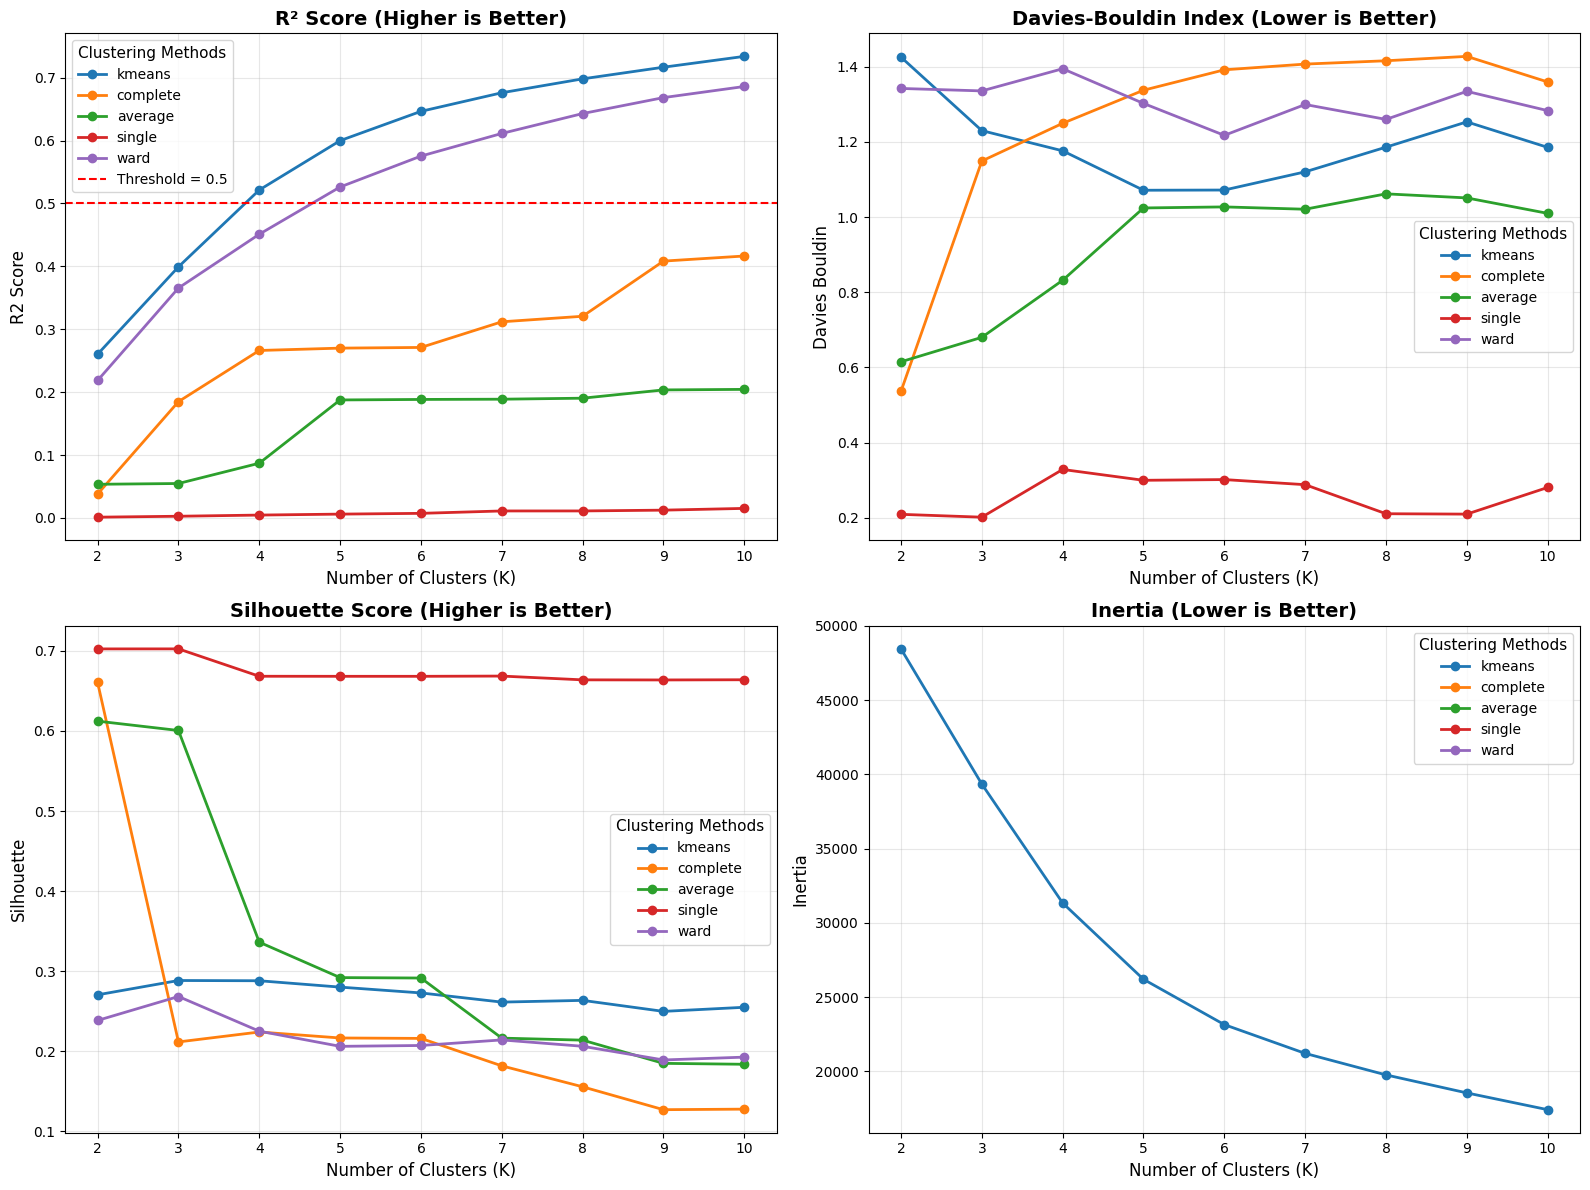

In [12]:
# --- Visualization: 4 Subplots (One per Metric, All Methods) ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
metrics_data = {
    'R2_Score': axes[0, 0],
    'Davies_Bouldin': axes[0, 1],
    'Silhouette': axes[1, 0],
    'Inertia': axes[1, 1]
}

metric_labels = {
    'R2_Score': 'R² Score (Higher is Better)',
    'Davies_Bouldin': 'Davies-Bouldin Index (Lower is Better)',
    'Silhouette': 'Silhouette Score (Higher is Better)',
    'Inertia': 'Inertia (Lower is Better)'
}

# Plot each metric
for metric_name, ax in metrics_data.items():
    for method_name, df_method in clustering_results.items():
        ax.plot(df_method['K'], df_method[metric_name], marker='o', label=method_name, linewidth=2)
    
    ax.set_title(metric_labels[metric_name], fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax.set_ylabel(metric_name.replace('_', ' '), fontsize=12)
    ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))

    # Add horizontal threshold line for R² Score
    if metric_name == 'R2_Score':
        ax.axhline(y=0.5, color='r', linestyle='--', label='Threshold = 0.5')
        ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()


We decide for K-Means with K = 4

In [13]:
# 1. Finales Clustering durchführen 
k_best_value = 4

kmeans_value = KMeans(n_clusters=k_best_value, init='k-means++', n_init=20, random_state=42)

value_labels = kmeans_value.fit_predict(df_value_based)

customers['valuebased_cluster'] = value_labels

In [14]:
df_profile_value = df_value_based.copy()
df_profile_value['Cluster'] = value_labels

df_profile_value

,Customer Lifetime Value,Income,total_points_accumulated,total_cost_redeemed,Cluster
Loyalty#,,,,,
480934,-0.605614,1.068659,1.338311,0.576033,0
549612,-0.605545,-1.243243,0.843514,1.584071,3
429460,-0.605524,-1.243243,-0.317841,-0.369294,3
608370,-0.605524,-1.243243,0.592203,0.896561,3
530508,-0.605080,1.981146,0.488700,-0.987124,0
...,...,...,...,...,...
823768,7.874405,-1.243243,0.770479,-0.987124,2
680886,8.759826,1.337732,0.447844,0.902368,2
776187,9.683862,-1.243243,1.210686,0.828042,2


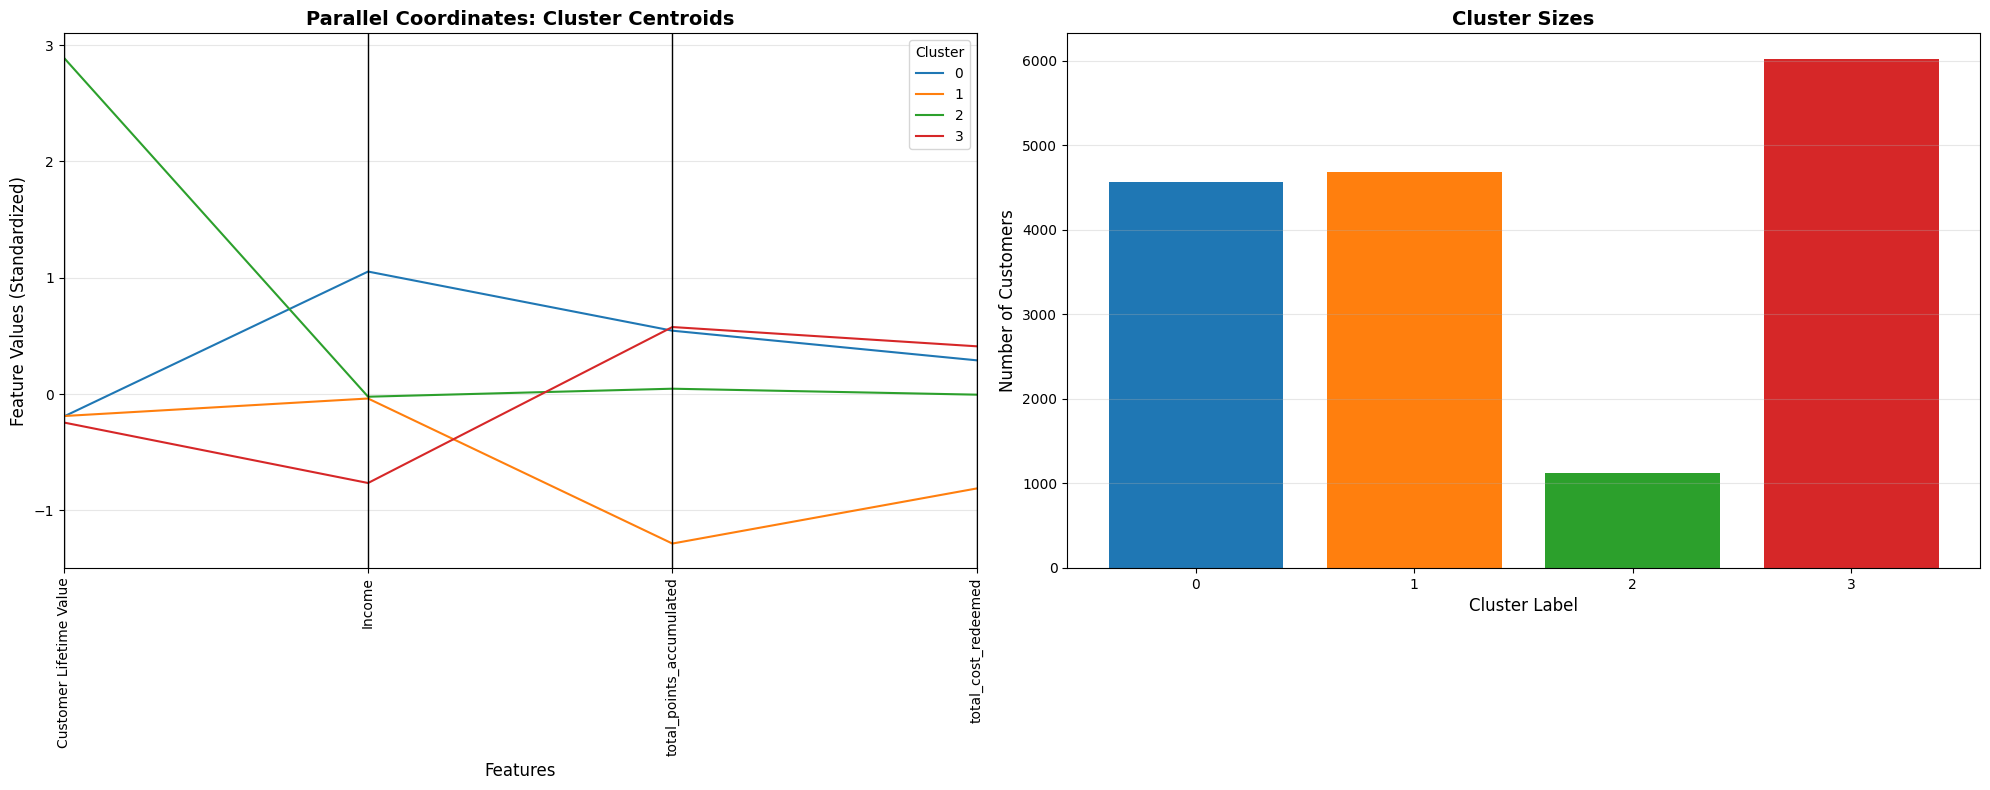

In [15]:
# Value based cluster profiling
df_profile_value = df_value_based.copy()
df_profile_value['Cluster'] = value_labels

# 3. Centroids berechnen (Durchschnittswerte pro Cluster)
df_centroids_value = df_profile_value.groupby('Cluster')[value_based_features].mean()

# --- Visualisierung 1: Parallel Coordinates & Cluster Sizes ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Parallel coordinates
# Wir nutzen reset_index(), damit 'cluster' eine Spalte für die Färbung ist
pd.plotting.parallel_coordinates(
    df_centroids_value.reset_index(),
    'Cluster',
    color=sns.color_palette('tab10', n_colors=k_best_value),
    ax=ax1
)
ax1.set_title('Parallel Coordinates: Cluster Centroids', fontsize=14, fontweight='bold')
ax1.set_ylabel('Feature Values (Standardized)', fontsize=12)
ax1.set_xlabel('Features', fontsize=12)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90) # Labels drehen für Lesbarkeit
ax1.grid(True, alpha=0.3)
ax1.legend(title='Cluster', loc='best')

# RIGHT PLOT: Cluster sizes
cluster_sizes = df_profile_value['Cluster'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=k_best_value)

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Cluster Label', fontsize=12)
ax2.set_ylabel('Number of Customers', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

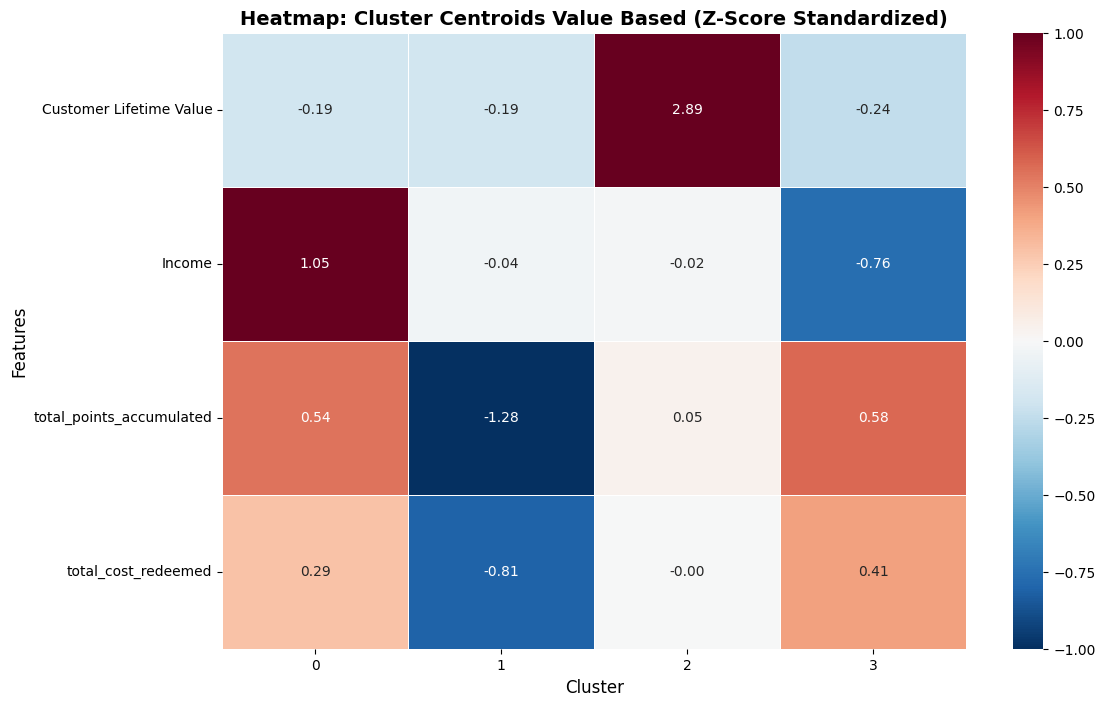

In [16]:
# --- Visualisierung 2: Heatmap der Centroids ---
plt.figure(figsize=(12, 8))

# Daten vorbereiten: Features als Zeilen
df_plot = df_centroids_value.T

# Transponieren (T), damit Features auf der Y-Achse sind
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Rot-Blau Farbverlauf (gut für Abweichungen vom Mittelwert)
    center=0,       # Zentriert bei 0 für standardisierte Daten
    annot=True,     # Werte anzeigen
    fmt='.2f',      # 2 Nachkommastellen
    linewidths=.5,
    vmin=-1,        # Minimum bei -1
    vmax=1          # Maximum bei 1
)

plt.title('Heatmap: Cluster Centroids Value Based (Z-Score Standardized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

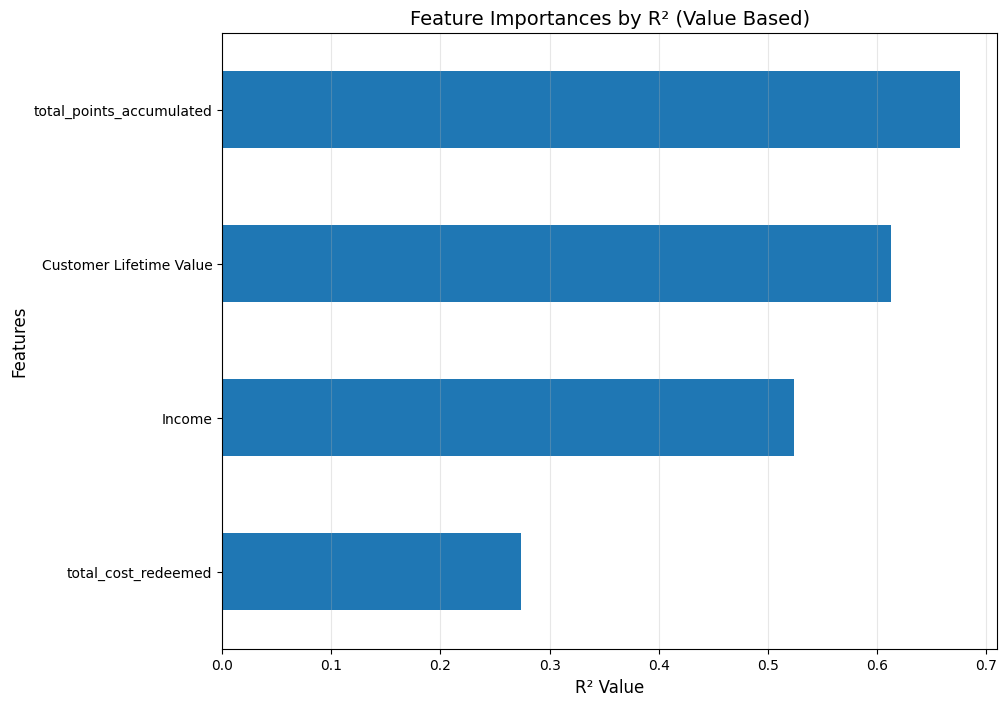

In [17]:
# Da 'r2_variables' nicht definiert ist, berechnen wir R2 für jedes Feature einzeln
# mit der existierenden 'get_rsq' Funktion.
r2_data = {}
for feature in value_based_features:
    # get_rsq erwartet eine Liste von Features, daher [feature]
    r2_data[feature] = get_rsq(df_profile_value, [feature], 'Cluster')

r2_feats = pd.Series(r2_data)

# Plotten
r2_feats.sort_values().plot.barh(figsize=(10, 8))
plt.title("Feature Importances by R² (Value Based)", fontsize=14)
plt.xlabel("R² Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

## 2.2 Demographic Clustering

Text for demographic

In [18]:
# Print number of metric features   
print ("Number of metric features:", len(demographic_features))

# check if metric or not 

for feature in demographic_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")


# Create the pandas dataframe df_demographic
df_demographic = pd.DataFrame(customers[demographic_features])

df_demographic.head()

Number of metric features: 9
Location Code_Suburban: Metric
Location Code_Urban: Metric
Gender_male: Metric
Education_College: Metric
Education_High School or Below: Metric
Education_Master: Metric
Education_Doctor: Metric
Marital Status_Married: Metric
Marital Status_Single: Metric


,Location Code_Suburban,Location Code_Urban,Gender_male,Education_College,Education_High School or Below,Education_Master,Education_Doctor,Marital Status_Married,Marital Status_Single
Loyalty#,,,,,,,,,
480934,0,1,0,0,0,0,0,1,0
549612,0,0,1,1,0,0,0,0,0
429460,0,1,1,1,0,0,0,0,1
608370,1,0,1,1,0,0,0,0,1
530508,1,0,1,0,0,0,0,1,0


Before starting with the first Clustering Method, we will remove highly correlated features from the dataset. Highly correlated features can negatively impact the performance of clustering algorithms (e.g., KMeans). We will use a correlation threshold of 0.8 to identify and remove highly correlated features.

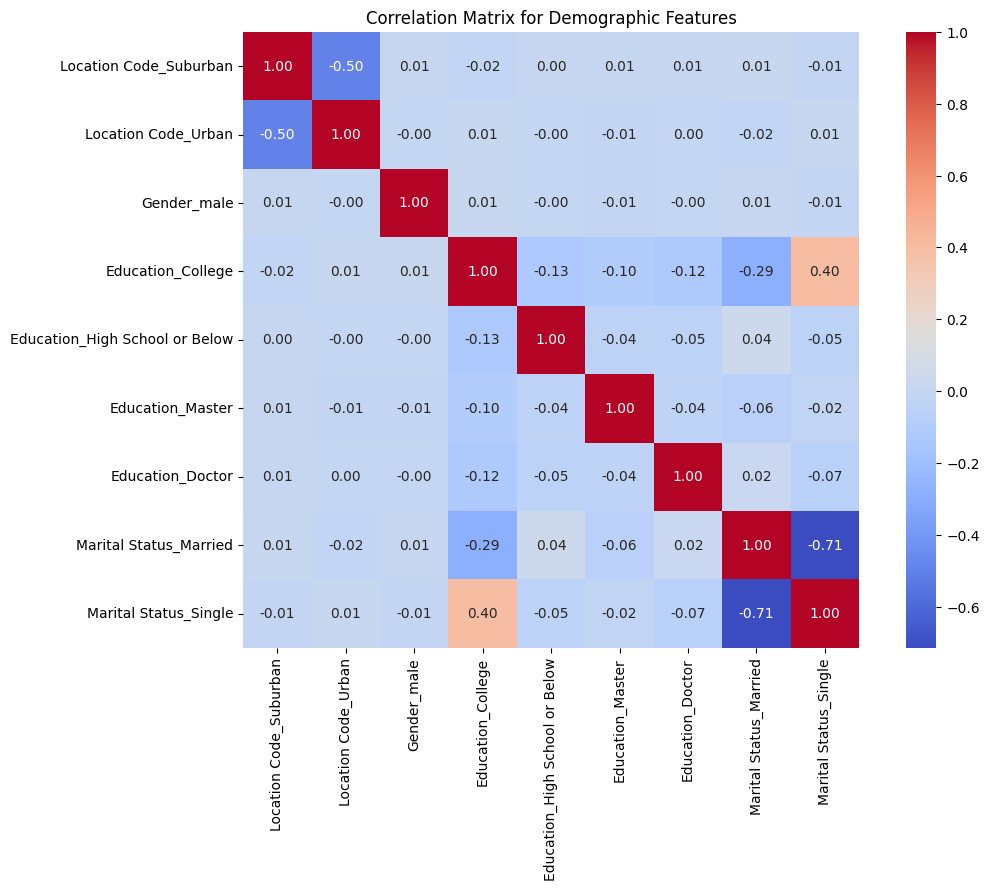

Pairs with correlation > 0.8 or < -0.8:
Series([], dtype: float64)


In [19]:
# Check for correlation inside the value based features
plt.figure(figsize=(12, 8))
correlation_matrix = df_demographic.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Demographic Features")
plt.show()

threshold = 0.8
unstacked = correlation_matrix.unstack()
high_corr = unstacked[(unstacked.abs() > threshold) & (unstacked != 1.0)].drop_duplicates()

print(f"Pairs with correlation > {threshold} or < -{threshold}:")
print(high_corr)

We will do K-Means++ Clustering and compare it with Hierarchical Clustering

In [20]:
# --- Comprehensive Clustering Evaluation with All Metrics ---

def evaluate_clustering_methods(data, feats, min_k=2, max_k=11):
    """
    Evaluates multiple clustering methods and calculates:
    - R2 Score
    - Davies-Bouldin Index (DBI)
    - Silhouette Score
    - Inertia (for KMeans-based methods)
    
    Returns a dictionary with DataFrames for each method.
    """
    
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Total Sum of Squares (SST) once for R2 calculation
    centroid = X.mean(axis=0)
    sst = np.sum((X - centroid) ** 2)
    
    # Initialize results dictionary
    results_by_method = {}
    
    # --- K-MEANS ---
    print("Evaluating K-Means...")
    kmeans_results = []
    kmeans_clusterer = KMeans(init='k-means++', n_init=20, random_state=42)
    
    for k in range(min_k, max_k):
        kmeans = clone(kmeans_clusterer).set_params(n_clusters=k)
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        ssw = kmeans.inertia_
        r2 = 1 - (ssw / sst)
        dbi = davies_bouldin_score(X, labels)
        sil = silhouette_score(X, labels)
        
        kmeans_results.append({
            'K': k,
            'R2_Score': r2,
            'Davies_Bouldin': dbi,
            'Silhouette': sil,
            'Inertia': ssw
        })
    
    df_kmeans = pd.DataFrame(kmeans_results)
    df_kmeans.loc[:, 'R2_Pct_Change'] = df_kmeans['R2_Score'].pct_change() * 100
    df_kmeans.loc[:, 'DBI_Pct_Change'] = df_kmeans['Davies_Bouldin'].pct_change() * 100
    df_kmeans.loc[:, 'Sil_Pct_Change'] = df_kmeans['Silhouette'].pct_change() * 100
    df_kmeans.loc[:, 'Inertia_Pct_Change'] = df_kmeans['Inertia'].pct_change() * 100
    
    results_by_method['kmeans'] = df_kmeans
    
    # --- HIERARCHICAL CLUSTERING (Various Linkages) ---
    hierarchical_clusterer = AgglomerativeClustering(metric='euclidean')
    
    for linkage_type in ['complete', 'average', 'single', 'ward']:
        print(f"Evaluating Hierarchical Clustering ({linkage_type})...")
        hc_results = []
        
        for k in range(min_k, max_k):
            hc = clone(hierarchical_clusterer).set_params(n_clusters=k, linkage=linkage_type)
            labels = hc.fit_predict(X)
            
            # Calculate metrics
            dbi = davies_bouldin_score(X, labels)
            sil = silhouette_score(X, labels)
            
            # Calculate R2 for hierarchical clustering
            df_concat = pd.concat([data, pd.Series(labels, name='labels', index=data.index)], axis=1)
            r2 = get_rsq(df_concat, feats, 'labels')
            
            # Hierarchical clustering doesn't have inertia, so we'll use None
            hc_results.append({
                'K': k,
                'R2_Score': r2,
                'Davies_Bouldin': dbi,
                'Silhouette': sil,
                'Inertia': np.nan  # Not applicable for hierarchical clustering
            })
        
        df_hc = pd.DataFrame(hc_results)
        df_hc.loc[:, 'R2_Pct_Change'] = df_hc['R2_Score'].pct_change() * 100
        df_hc.loc[:, 'DBI_Pct_Change'] = df_hc['Davies_Bouldin'].pct_change() * 100
        df_hc.loc[:, 'Sil_Pct_Change'] = df_hc['Silhouette'].pct_change() * 100
        df_hc.loc[:, 'Inertia_Pct_Change'] = df_hc['Inertia'].pct_change() * 100
        
        results_by_method[linkage_type] = df_hc
    
    return results_by_method

# --- EXECUTION ---
print("Starting comprehensive clustering evaluation...\n")
clustering_results_demographic = evaluate_clustering_methods(df_demographic, demographic_features, min_k=2, max_k=11)

# --- DISPLAY RESULTS FOR EACH METHOD ---
for method_name, df_method in clustering_results_demographic.items():
    print(f"\n{'='*80}")
    print(f"METHOD: {method_name.upper()}")
    print(f"{'='*80}")
    display(df_method.round(4))
    
    # Highlight best K for each metric
    print(f"\nBest configurations for {method_name}:")
    print(f"  - Highest R2: K={df_method.loc[df_method['R2_Score'].idxmax(), 'K']:.0f}")
    print(f"  - Lowest Davies-Bouldin: K={df_method.loc[df_method['Davies_Bouldin'].idxmin(), 'K']:.0f}")
    print(f"  - Highest Silhouette: K={df_method.loc[df_method['Silhouette'].idxmax(), 'K']:.0f}")

Starting comprehensive clustering evaluation...

Evaluating K-Means...
Evaluating Hierarchical Clustering (complete)...
Evaluating Hierarchical Clustering (average)...
Evaluating Hierarchical Clustering (single)...
Evaluating Hierarchical Clustering (ward)...

METHOD: KMEANS


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.2498,1.7018,0.2697,17668.9943,NaN,NaN,NaN,NaN
1,3,0.3874,1.4813,0.2758,14427.9751,55.0991,-12.9554,2.2495,-18.3430
2,4,0.4699,1.3852,0.2970,12485.0911,21.2961,-6.4873,7.6944,-13.4661
3,5,0.5247,1.4855,0.3190,11194.9645,11.6584,7.2363,7.3843,-10.3333
4,6,0.5617,1.3738,0.3199,10322.8750,7.0579,-7.5148,0.2916,-7.7900
5,7,0.6077,1.2513,0.3691,9238.4807,8.1975,-8.9209,15.3704,-10.5048
6,8,0.6489,1.1901,0.4236,8268.8937,6.7743,-4.8911,14.7754,-10.4951
7,9,0.6586,1.2000,0.4177,8039.4070,1.5017,0.8340,-1.3819,-2.7753
8,10,0.6962,1.1470,0.4570,7154.7826,5.7029,-4.4152,9.3931,-11.0036



Best configurations for kmeans:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=10
  - Highest Silhouette: K=10

METHOD: COMPLETE


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.1205,1.8942,0.1411,NaN,NaN,NaN,NaN,NaN
1,3,0.2214,1.8033,0.1496,NaN,83.6985,-4.8031,5.9920,NaN
2,4,0.3503,2.0063,0.2023,NaN,58.2599,11.2576,35.2485,NaN
3,5,0.3862,2.0774,0.2018,NaN,10.2393,3.5445,-0.2857,NaN
4,6,0.4257,2.1192,0.2245,NaN,10.2279,2.0110,11.2649,NaN
5,7,0.4416,1.9920,0.2293,NaN,3.7287,-6.0024,2.1620,NaN
6,8,0.4633,1.9330,0.2426,NaN,4.9232,-2.9622,5.7705,NaN
7,9,0.5346,1.6816,0.2881,NaN,15.3877,-13.0016,18.7875,NaN
8,10,0.5686,1.5760,0.3086,NaN,6.3553,-6.2805,7.1069,NaN



Best configurations for complete:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=10
  - Highest Silhouette: K=10

METHOD: AVERAGE


...


Best configurations for average:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=10
  - Highest Silhouette: K=2

METHOD: SINGLE


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.0023,0.7219,0.1707,NaN,NaN,NaN,NaN,NaN
1,3,0.0035,0.7557,0.0949,NaN,52.3569,4.6832,-44.4049,NaN
2,4,0.0058,0.7668,0.0563,NaN,68.9098,1.4685,-40.6618,NaN
3,5,0.0071,0.7677,0.0170,NaN,22.0061,0.1239,-69.8718,NaN
4,6,0.0086,0.7591,0.0171,NaN,20.8358,-1.1317,0.6650,NaN
5,7,0.0129,0.7879,-0.0156,NaN,49.8372,3.7969,-191.1210,NaN
6,8,0.0149,0.7886,-0.0637,NaN,15.1073,0.0980,309.4019,NaN
7,9,0.0165,0.7885,-0.0828,NaN,10.7691,-0.0172,29.9447,NaN
8,10,0.0185,0.7877,-0.0818,NaN,12.1022,-0.1003,-1.1464,NaN



Best configurations for single:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=2
  - Highest Silhouette: K=2

METHOD: WARD


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.2065,1.8761,0.2381,NaN,NaN,NaN,NaN,NaN
1,3,0.2868,1.9061,0.2166,NaN,38.9206,1.5954,-9.0383,NaN
2,4,0.3626,1.7797,0.1993,NaN,26.4160,-6.6304,-7.9911,NaN
3,5,0.4286,1.6824,0.2413,NaN,18.2027,-5.4649,21.0748,NaN
4,6,0.4766,1.6608,0.2636,NaN,11.1981,-1.2836,9.2532,NaN
5,7,0.5160,1.8536,0.2907,NaN,8.2724,11.6087,10.2536,NaN
6,8,0.5499,1.8030,0.3112,NaN,6.5614,-2.7338,7.0738,NaN
7,9,0.5813,1.5181,0.3284,NaN,5.7165,-15.8026,5.5315,NaN
8,10,0.6092,1.4592,0.3324,NaN,4.7957,-3.8766,1.2074,NaN



Best configurations for ward:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=10
  - Highest Silhouette: K=10


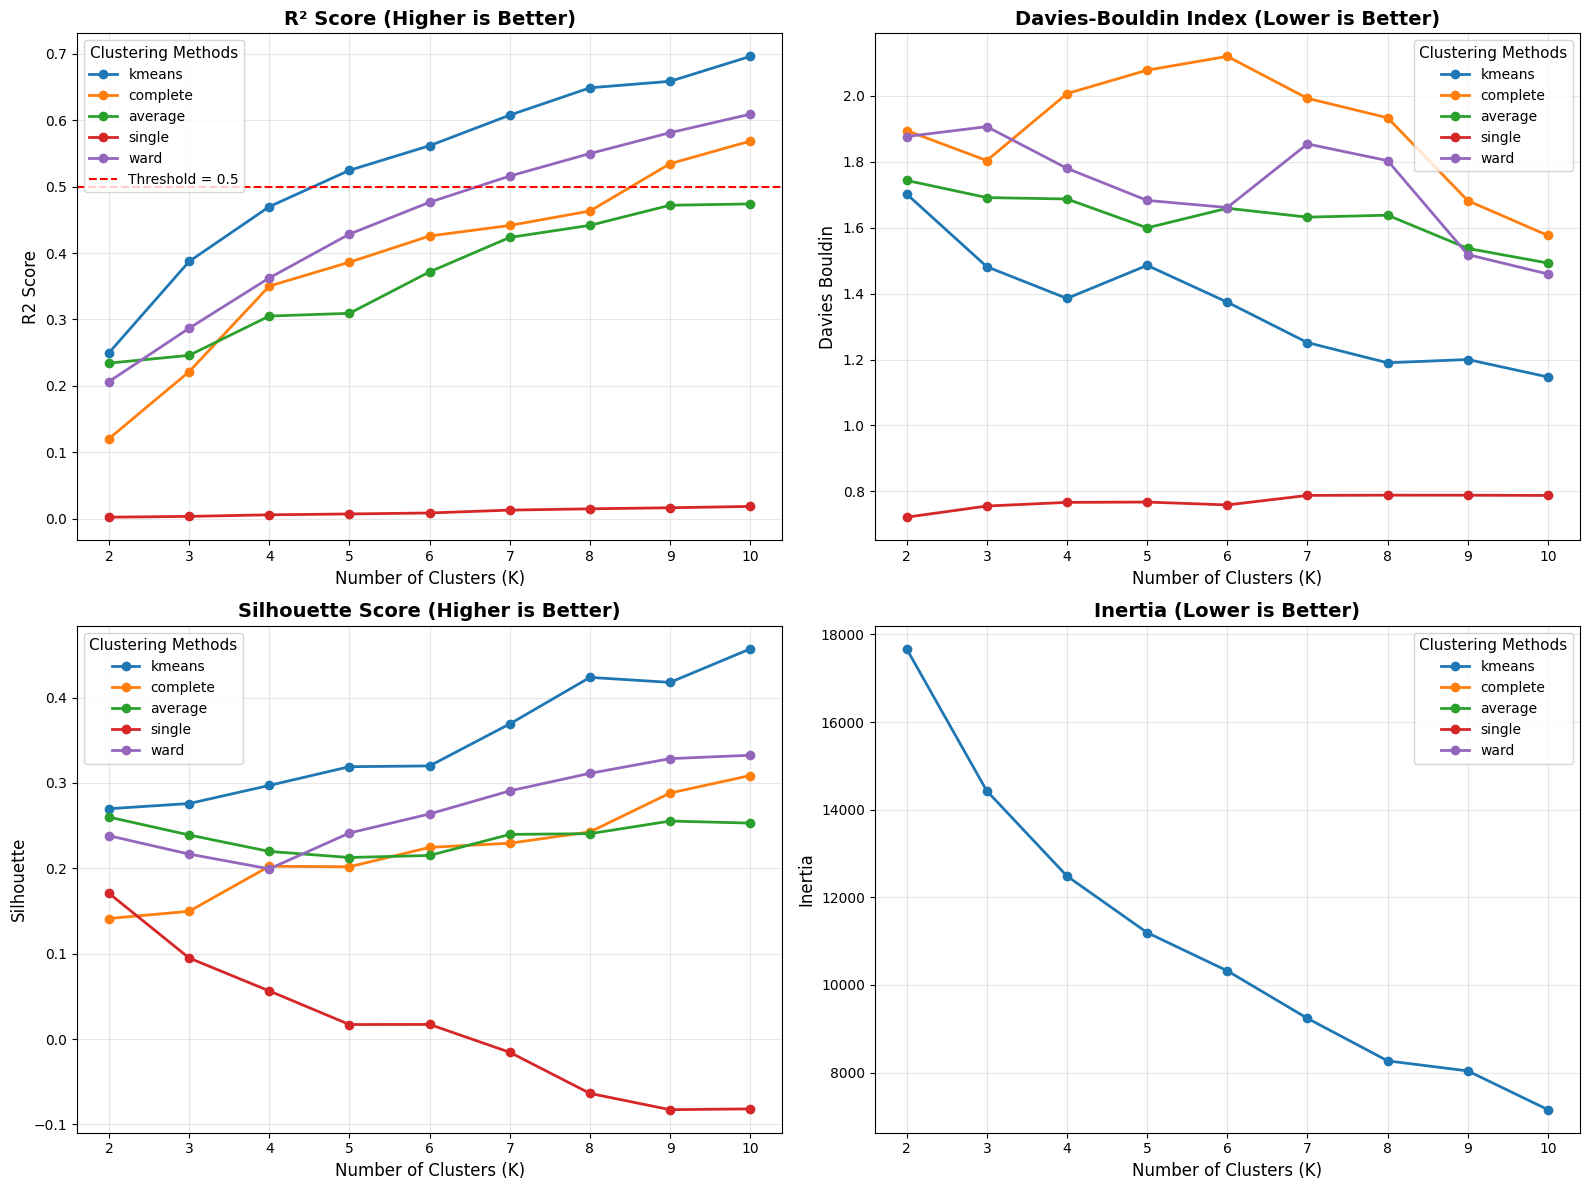

In [21]:
# --- Visualization: 4 Subplots (One per Metric, All Methods) ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
metrics_data = {
    'R2_Score': axes[0, 0],
    'Davies_Bouldin': axes[0, 1],
    'Silhouette': axes[1, 0],
    'Inertia': axes[1, 1]
}

metric_labels = {
    'R2_Score': 'R² Score (Higher is Better)',
    'Davies_Bouldin': 'Davies-Bouldin Index (Lower is Better)',
    'Silhouette': 'Silhouette Score (Higher is Better)',
    'Inertia': 'Inertia (Lower is Better)'
}

# Plot each metric
for metric_name, ax in metrics_data.items():
    for method_name, df_method in clustering_results_demographic.items():
        ax.plot(df_method['K'], df_method[metric_name], marker='o', label=method_name, linewidth=2)
    
    ax.set_title(metric_labels[metric_name], fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax.set_ylabel(metric_name.replace('_', ' '), fontsize=12)
    ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))

    # Add horizontal threshold line for R² Score
    if metric_name == 'R2_Score':
        ax.axhline(y=0.5, color='r', linestyle='--', label='Threshold = 0.5')
        ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()


We decide for K-Means with K = 5

In [22]:
# 1. Finales Clustering durchführen 
k_best_demo = 5

kmeans_demo = KMeans(n_clusters=k_best_demo, init='k-means++', n_init=20, random_state=42)

demo_labels = kmeans_demo.fit_predict(df_demographic)

customers['demographic_cluster'] = demo_labels

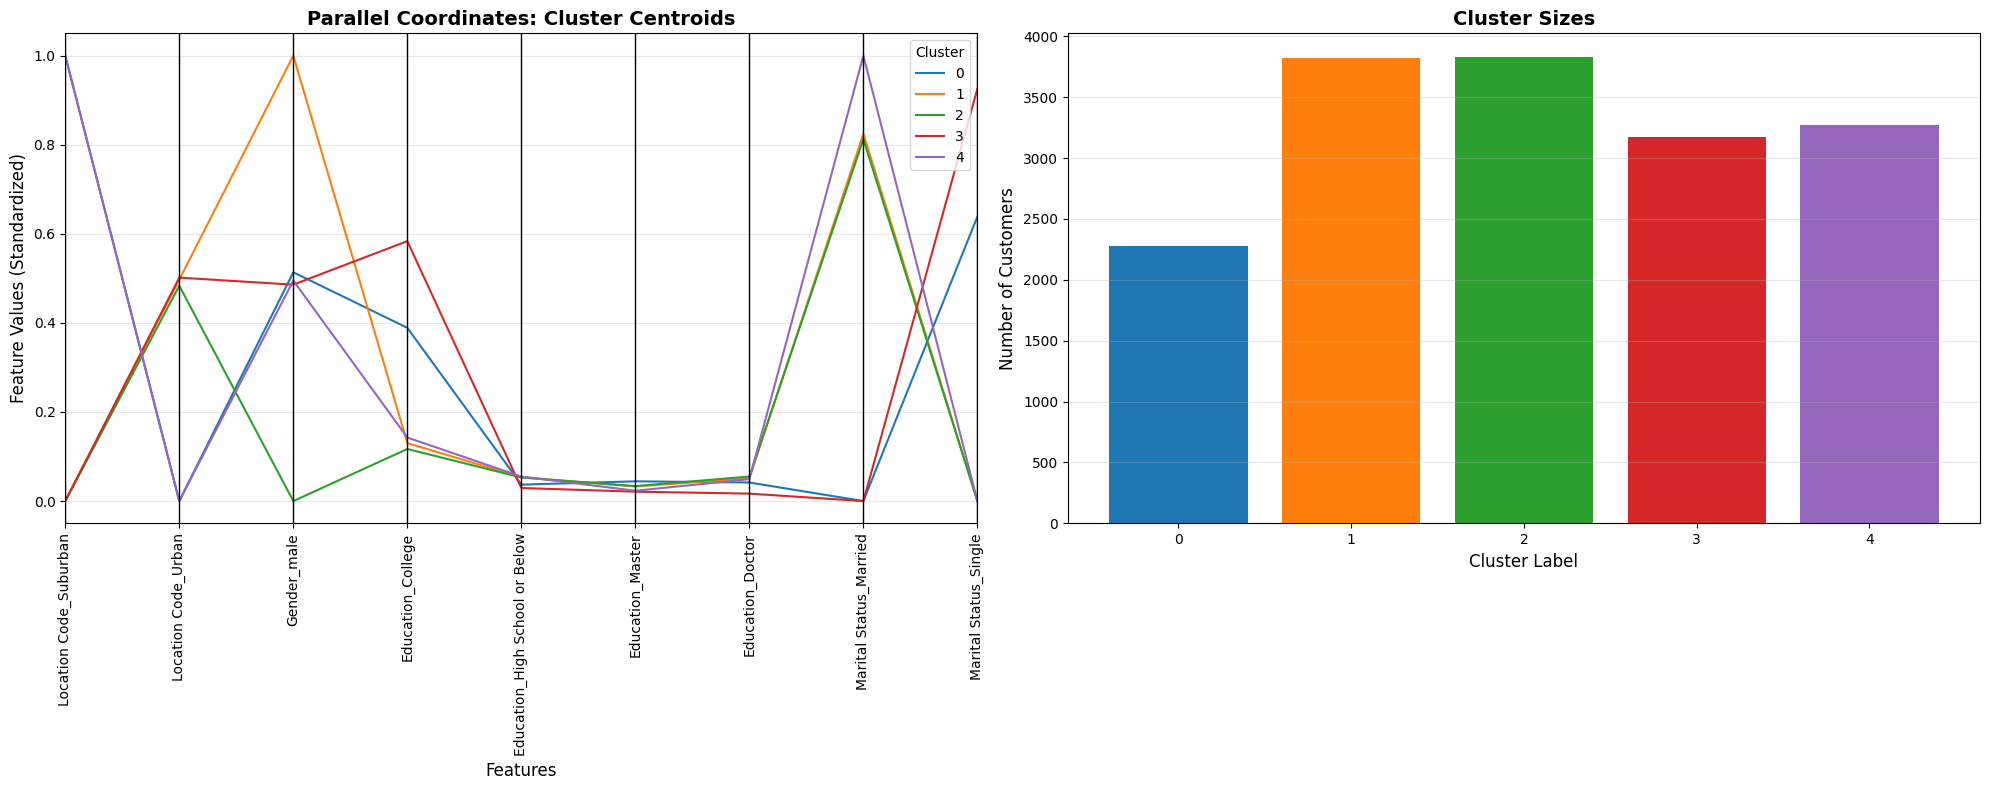

In [23]:
# Demographic cluster profiling
df_profile_demo = df_demographic.copy()
df_profile_demo['cluster'] = demo_labels

# 3. Centroids berechnen (Durchschnittswerte pro Cluster)
df_centroids_demo = df_profile_demo.groupby('cluster')[demographic_features].mean()

# --- Visualisierung 1: Parallel Coordinates & Cluster Sizes ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Parallel coordinates
# Wir nutzen reset_index(), damit 'cluster' eine Spalte für die Färbung ist
pd.plotting.parallel_coordinates(
    df_centroids_demo.reset_index(),
    'cluster',
    color=sns.color_palette('tab10', n_colors=k_best_demo),
    ax=ax1
)
ax1.set_title('Parallel Coordinates: Cluster Centroids', fontsize=14, fontweight='bold')
ax1.set_ylabel('Feature Values (Standardized)', fontsize=12)
ax1.set_xlabel('Features', fontsize=12)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90) # Labels drehen für Lesbarkeit
ax1.grid(True, alpha=0.3)
ax1.legend(title='Cluster', loc='best')

# RIGHT PLOT: Cluster sizes
cluster_sizes = df_profile_demo['cluster'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=k_best_demo)

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Cluster Label', fontsize=12)
ax2.set_ylabel('Number of Customers', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

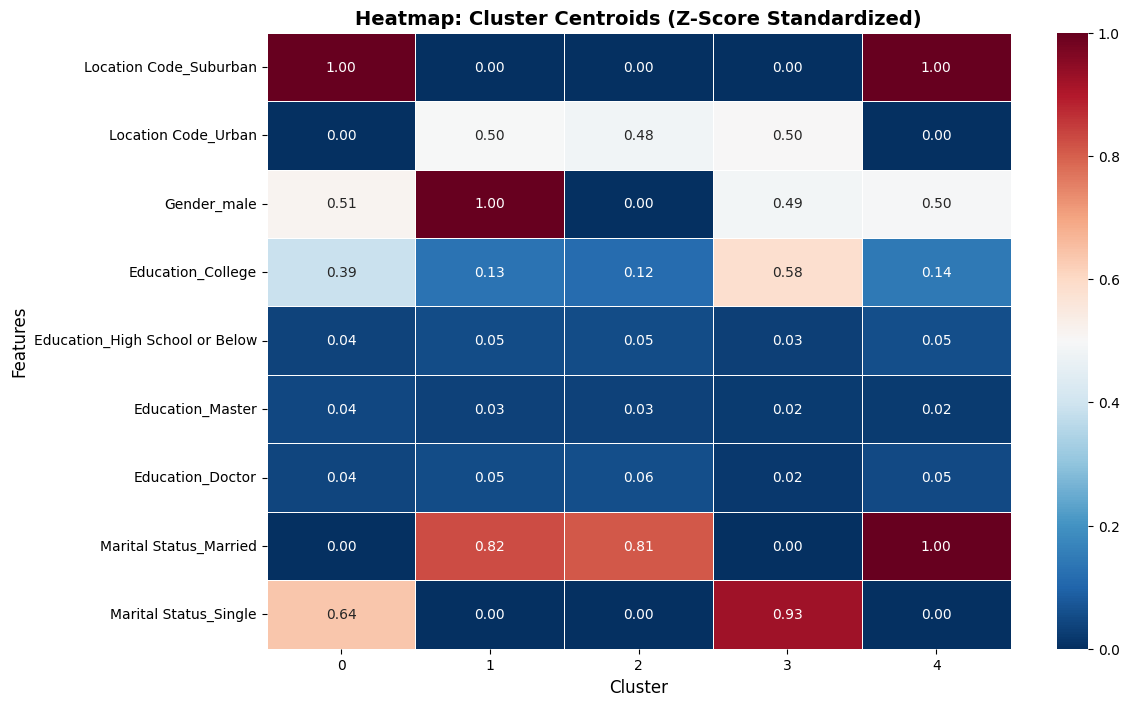

In [24]:
# --- Visualisierung 2: Heatmap der Centroids ---
plt.figure(figsize=(12, 8))

# Daten vorbereiten: Features als Zeilen
df_plot = df_centroids_demo.T

# Transponieren (T), damit Features auf der Y-Achse sind
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Rot-Blau Farbverlauf (gut für Abweichungen vom Mittelwert)
    center=0.5,       # Zentriert bei 0 für standardisierte Daten
    annot=True,     # Werte anzeigen
    fmt='.2f',      # 2 Nachkommastellen
    linewidths=.5,
    vmin=0,        # Minimum bei -1
    vmax=1          # Maximum bei 1
)

plt.title('Heatmap: Cluster Centroids (Z-Score Standardized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

Number of customers in each cluster:
Cluster 0: 2278 customers
Cluster 1: 3818 customers
Cluster 2: 3833 customers
Cluster 3: 3172 customers
Cluster 4: 3274 customers


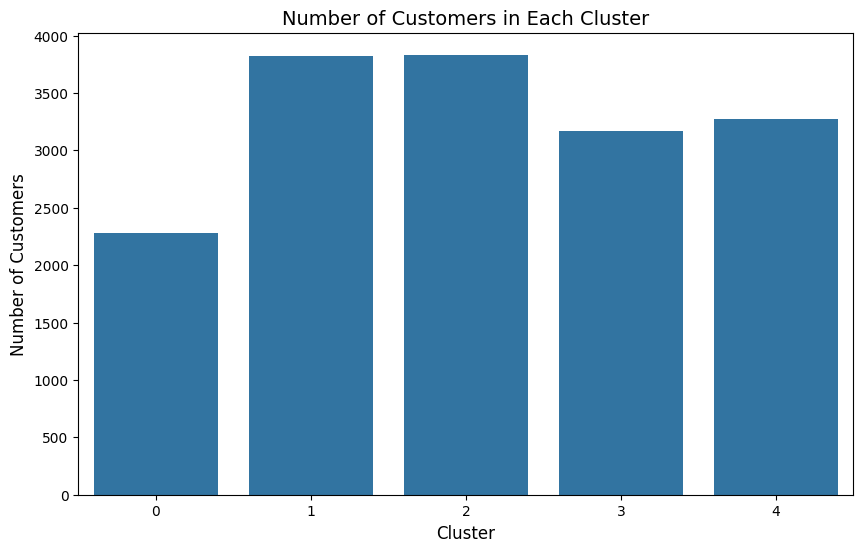

In [25]:
# Count the number of customers in each cluster and display the result and plot it
cluster_counts = df_profile_demo['cluster'].value_counts().sort_index()
print("Number of customers in each cluster:")
for cluster_label, count in cluster_counts.items():
    print(f"Cluster {cluster_label}: {count} customers")

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title('Number of Customers in Each Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()



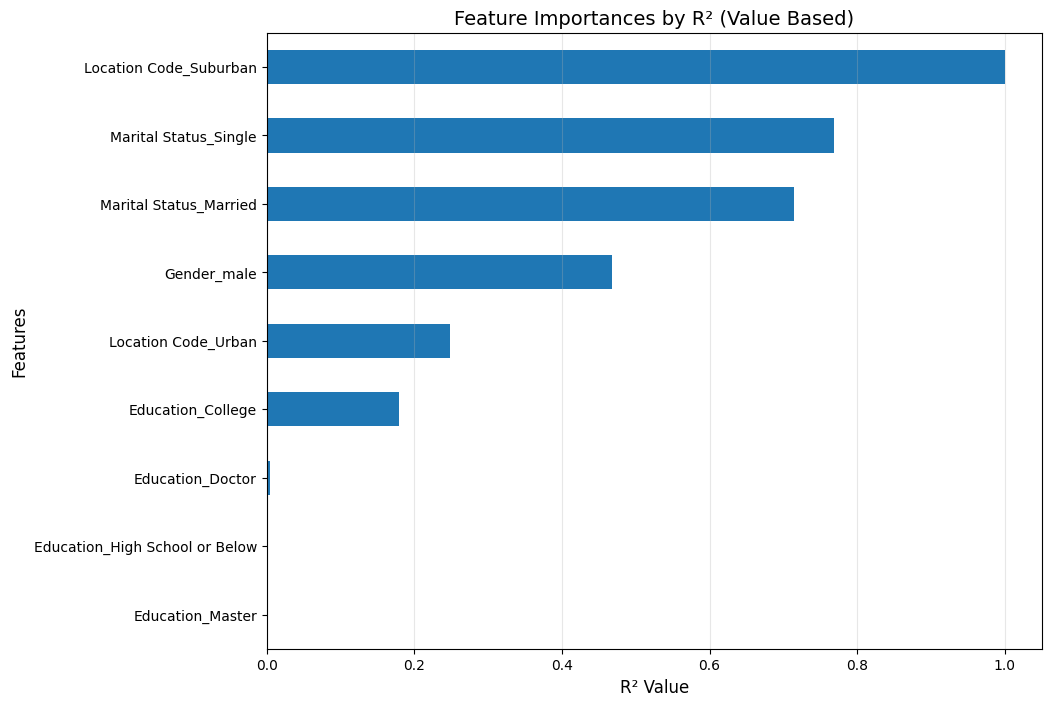

In [26]:
# Da 'r2_variables' nicht definiert ist, berechnen wir R2 für jedes Feature einzeln
# mit der existierenden 'get_rsq' Funktion.
r2_data = {}
for feature in demographic_features:
    # get_rsq erwartet eine Liste von Features, daher [feature]
    r2_data[feature] = get_rsq(df_profile_demo, [feature], 'cluster')

r2_feats = pd.Series(r2_data)

# Plotten
r2_feats.sort_values().plot.barh(figsize=(10, 8))
plt.title("Feature Importances by R² (Value Based)", fontsize=14)
plt.xlabel("R² Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

# 3 Merging Clusters

Cross-Tabulation Segmentation

In [27]:
customers.head()

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,...,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,valuebased_cluster,demographic_cluster
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,-1.064828,0.559917,M2Z 4K1,female,...,0,1,0,0,0,0,0,1,0,2
549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,1.926313,-0.973351,T3G 6Y6,male,...,0,0,0,0,0,0,0,0,3,3
429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,0.637565,-1.406246,V6E 3D9,male,...,0,0,0,0,0,0,0,1,3,3
608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,-1.064828,0.559917,P1W 1K4,male,...,0,1,0,0,0,0,1,0,3,0
530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,-0.527905,0.724889,J8Y 3Z5,male,...,0,0,0,1,0,0,1,0,0,4


In [28]:
# Cell 16: Calculate centroids for each combination
df_centroids = customers.groupby(['demographic_cluster', 'valuebased_cluster'])[metric_features].mean()
df_centroids.head

<bound method NDFrame.head of                                         Location Code_Suburban  \
demographic_cluster valuebased_cluster                           
0                   0                                      1.0   
                    1                                      1.0   
                    2                                      1.0   
                    3                                      1.0   
1                   0                                      0.0   
                    1                                      0.0   
                    2                                      0.0   
                    3                                      0.0   
2                   0                                      0.0   
                    1                                      0.0   
                    2                                      0.0   
                    3                                      0.0   
3                   0                         

In [29]:
print(f"\nCentroids shape: {df_centroids.shape}")


Centroids shape: (20, 13)


In [86]:
# Print all unique values of location_code 
print(customers['Education'].unique())

['Bachelor' 'College' 'Master' 'High School or Below' 'Doctor']


#### We will assume ward linkage 

#### But need to decide the number of final clusters 

In [30]:
# Fit hierarchical clustering with distance tracking
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels = hclust.fit_predict(df_centroids)

# Build linkage matrix for dendrogram
# (Adapted from scikit-learn documentation)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

for i, merge in enumerate(hclust.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # Leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([
    hclust.children_,
    hclust.distances_,
    counts
]).astype(float)

print("Linkage matrix ready for dendrogram!")

Linkage matrix ready for dendrogram!


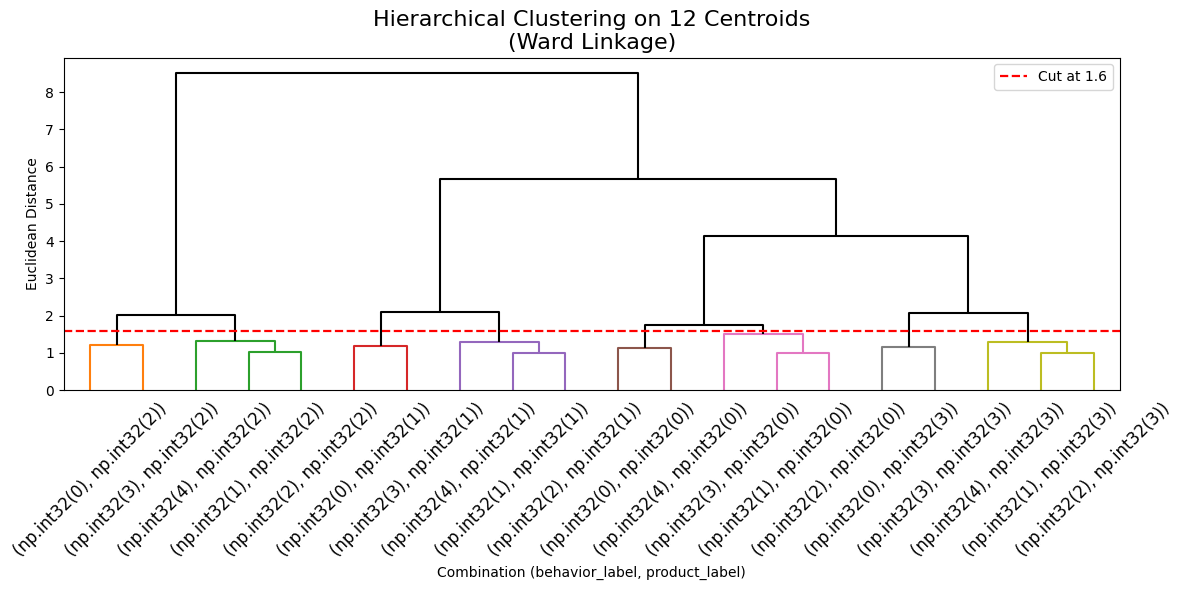

In [31]:
# Cell 18: Plot dendrogram with cutting options
fig = plt.figure(figsize=(12, 6))

# Potential cutting heights to consider
y_threshold = 1.6  # Can adjust this!

dendrogram(
    linkage_matrix,
    labels=df_centroids.index,
    color_threshold=y_threshold,
    above_threshold_color='k'
)

plt.axhline(y=y_threshold, color='r', linestyle='--', linewidth=1.6, label=f'Cut at {y_threshold}')

plt.title(f'Hierarchical Clustering on 12 Centroids\n(Ward Linkage)', fontsize=16)
plt.xlabel('Combination (behavior_label, product_label)')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
# ===========================================================
# Apply the final HC solution to the combined centroids 
# ===========================================================

n_final_clusters = 8

hclust_final = AgglomerativeClustering(
    linkage='ward',
    n_clusters=n_final_clusters
)

hclust_final_labels = hclust_final.fit_predict(df_centroids)
hclust_final_labels

array([2, 2, 5, 2, 4, 3, 7, 3, 4, 6, 5, 3, 6, 0, 0, 0, 1, 1, 1, 1])

In [70]:
# Add to centroids dataframe
df_centroids['merged_labels'] = hclust_final_labels
df_centroids

Location Code_Suburban  \
demographic_cluster valuebased_cluster                           
0                   0                                      1.0   
                    1                                      1.0   
                    2                                      1.0   
                    3                                      1.0   
1                   0                                      0.0   
                    1                                      0.0   
                    2                                      0.0   
                    3                                      0.0   
2                   0                                      0.0   
                    1                                      0.0   
                    2                                      0.0   
                    3                                      0.0   
3                   0                                      0.0   
                    1                                      0.0   
                    2                                      0.0   
                    3                                      0.0   
4                   0                                      1.0   
                    1                                      1.0   
                    2                                      1.0   
                    3                                      1.0   

                                        Location Code_Urban  Gender_male  \
demographic_cluster valuebased_cluster                                     
0                   0                              0.000000     0.531780   
                    1                              0.000000     0.496229   
                    2                              0.000000     0.528571   
                    3                              0.000000     0.514457   
1                   0                              0.489482     1.000000   
                    1                              0.493163     1.000000   
                    2                              0.494737     1.000000   
                    3                              0.508333     1.000000   
2                   0                              0.498851     0.000000   
                    1                              0.488160     0.000000   
                    2                              0.463602     0.000000   
                    3                              0.466210     0.000000   
3                   0                              0.537344     0.470954   
                    1                              0.474537     0.482639   
                    2                              0.474419     0.432558   
                    3                              0.509001     0.499069   
4                   0                              0.000000     0.505639   
                    1                              0.000000     0.488494   
                    2                              0.000000     0.546296   
                    3                              0.000000     0.479769   

                                        Education_College  \
demographic_cluster valuebased_cluster                      
0                   0                            0.000000   
                    1                            0.363499   
                    2                            0.357143   
                    3                            0.593220   
1                   0                            0.000000   
                    1                            0.123974   
                    2                            0.129825   
                    3                            0.270000   
2                   0                            0.000000   
                    1                            0.114754   
                    2                            0.114943   
                    3                            0.249786   
3                   0                            0.000000   

In [71]:
cluster_mapper = df_centroids['merged_labels'].to_dict()
cluster_mapper  

{(0, 0): 2,
 (0, 1): 2,
 (0, 2): 5,
 (0, 3): 2,
 (1, 0): 4,
 (1, 1): 3,
 (1, 2): 7,
 (1, 3): 3,
 (2, 0): 4,
 (2, 1): 6,
 (2, 2): 5,
 (2, 3): 3,
 (3, 0): 6,
 (3, 1): 0,
 (3, 2): 0,
 (3, 3): 0,
 (4, 0): 1,
 (4, 1): 1,
 (4, 2): 1,
 (4, 3): 1}

In [72]:
# Cell 21: Map merged labels back to all customers
customers['merged_labels'] = customers.apply(
    lambda row: cluster_mapper[(row['demographic_cluster'], row['valuebased_cluster'])],
    axis=1
)
customers

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio,LoyaltyStatus_Nova,LoyaltyStatus_Star,EnrollmentType_Standard,Gender_male,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,Province or State_British Columbia,Province or State_Manitoba,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,valuebased_cluster,demographic_cluster,merged_labels
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,-1.064828,0.559917,M2Z 4K1,female,Bachelor,Urban,1.068659,Married,Star,2019-02-15,NaN,-0.605614,Standard,1,-0.072878,1.107125,0.853643,1.338111,1.338311,0.564680,0.576033,1.338112,-0.047634,0.342580,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,2,4
549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,1.926313,-0.973351,T3G 6Y6,male,College,Rural,-1.243243,Divorced,Star,2019-03-09,NaN,-0.605545,Standard,1,-0.102559,1.892954,-0.181654,0.843650,0.843514,1.591410,1.584071,0.843651,0.584566,-0.902122,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,3,0
429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,0.637565,-1.406246,V6E 3D9,male,College,Urban,-1.243243,Single,Star,2017-07-14,2021-01-08,-0.605524,Standard,0,0.229333,-0.292522,0.133436,-0.317820,-0.317841,-0.358503,-0.369294,-0.317819,-0.137006,0.342580,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,3,3,0
608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,-1.064828,0.559917,P1W 1K4,male,College,Suburban,-1.243243,Single,Star,2016-02-17,NaN,-0.605524,Standard,1,1.403096,0.555749,0.943669,0.592202,0.592203,0.887816,0.896561,0.592203,0.333447,0.454587,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,3,0,2
530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,-0.527905,0.724889,J8Y 3Z5,male,Bachelor,Suburban,1.981146,Married,Star,2017-10-25,NaN,-0.605080,2021 Promotion,1,0.572018,0.446770,1.123721,0.488742,0.488700,-0.987825,-0.987124,0.488742,-0.696816,0.702406,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823768,Mandy,Sammarco,Mandy Sammarco,Canada,British Columbia,Vancouver,0.637565,-1.406246,V6E 3Z3,female,College,Rural,-1.243243,Married,Star,2015-12-22,NaN,7.874405,Standard,1,1.479998,0.110996,-0.856849,0.770363,0.770479,-0.987825,-0.987124,0.770363,-0.696816,-1.015542,0,1,1,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,2,2,5
680886,Jamee,Ahlm,Jamee Ahlm,Canada,Saskatchewan,Regina,0.989105,-0.574521,S1J 3C5,female,Bachelor,Rural,1.337732,Married,Star,2017-09-06,NaN,8.759826,Standard,1,0.638126,1.539508,1.123721,0.448107,0.447844,0.899680,0.902368,0.448107,0.406936,0.026105,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,2,2,5
776187,Janina,Lumb,Janina Lumb,Canada,British Columbia,Vancouver,0.637565,-1.406246,V5R 1W3,male,College,Urban,-1.243243,Single,Star,2017-03-24,NaN,9.683862,Standard,1,0.862086,1.107125,0.448527,1.210680,1.210686,0.819080,0.828042,1.210681,0.090912,-0.354515,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,2,3,0


In [73]:
print(customers['merged_labels'].value_counts().sort_index())

merged_labels
0    2690
1    3274
2    2138
3    3466
4    2541
5     401
6    1580
7     285
Name: count, dtype: int64


In [74]:
# Quick distinctiveness check (R²)
r2_merged = get_rsq(customers, metric_features, 'merged_labels')
print(f"\nMerged clustering R²: {r2_merged:.4f}")


Merged clustering R²: 0.2778


# Profiling 

In [75]:
# Show all columns of customers dataframe fully without truncation
pd.set_option('display.max_columns', None)
customers.head(10)

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio,LoyaltyStatus_Nova,LoyaltyStatus_Star,EnrollmentType_Standard,Gender_male,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,Province or State_British Columbia,Province or State_Manitoba,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,valuebased_cluster,demographic_cluster,merged_labels
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,-1.064828,0.559917,M2Z 4K1,female,Bachelor,Urban,1.068659,Married,Star,2019-02-15,NaN,-0.605614,Standard,1,-0.072878,1.107125,0.853643,1.338111,1.338311,0.564680,0.576033,1.338112,-0.047634,0.342580,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,2,4
549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,1.926313,-0.973351,T3G 6Y6,male,College,Rural,-1.243243,Divorced,Star,2019-03-09,NaN,-0.605545,Standard,1,-0.102559,1.892954,-0.181654,0.843650,0.843514,1.591410,1.584071,0.843651,0.584566,-0.902122,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,3,0
429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,0.637565,-1.406246,V6E 3D9,male,College,Urban,-1.243243,Single,Star,2017-07-14,2021-01-08,-0.605524,Standard,0,0.229333,-0.292522,0.133436,-0.317820,-0.317841,-0.358503,-0.369294,-0.317819,-0.137006,0.342580,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,3,3,0
608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,-1.064828,0.559917,P1W 1K4,male,College,Suburban,-1.243243,Single,Star,2016-02-17,NaN,-0.605524,Standard,1,1.403096,0.555749,0.943669,0.592202,0.592203,0.887816,0.896561,0.592203,0.333447,0.454587,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,3,0,2
530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,-0.527905,0.724889,J8Y 3Z5,male,Bachelor,Suburban,1.981146,Married,Star,2017-10-25,NaN,-0.605080,2021 Promotion,1,0.572018,0.446770,1.123721,0.488742,0.488700,-0.987825,-0.987124,0.488742,-0.696816,0.702406,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,4,1
927943,Hue,Sellner,Hue Sellner,Canada,Ontario,Toronto,-1.064828,0.559917,P5S 6R4,female,College,Urban,-1.243243,Single,Star,2017-06-09,NaN,-0.602864,Standard,1,0.758201,1.107125,-0.091628,1.413684,1.413852,1.492629,1.502778,1.413683,0.315910,-0.463190,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,3,3,0
188893,Nakia,Cash,Nakia Cash,Canada,Ontario,Trenton,-0.929379,0.641143,K8V 4B2,male,Bachelor,Suburban,1.830856,Married,Star,2019-12-08,NaN,-0.602347,Standard,1,-0.472227,0.744254,1.303773,0.858874,0.859006,-0.083063,-0.075476,0.858874,-0.249956,0.619249,0,1,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,4,1
852392,Arlene,Conterras,Arlene Conterras,Canada,Quebec,Montreal,-0.505842,0.821365,H2Y 2W2,female,Bachelor,Suburban,1.830856,Married,Star,2018-05-30,NaN,-0.602347,Standard,1,0.279251,-0.212996,0.853643,0.397743,0.397792,1.245235,1.243800,0.397744,0.638921,1.122557,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,4,1
866307,Dustin,Recine,Dustin Recine,Canada,Ontario,Toronto,-1.064828,0.559917,M8Y 4K8,male,Bachelor,Suburban,1.830856,Married,Star,2019-10-14,NaN,-0.602347,Standard,1,-0.398024,0.918032,1.438812,0.089108,0.089025,1.484325,1.480712,0.089109,1.025327,0.600905,0,1,1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,4,1


## Metric features 

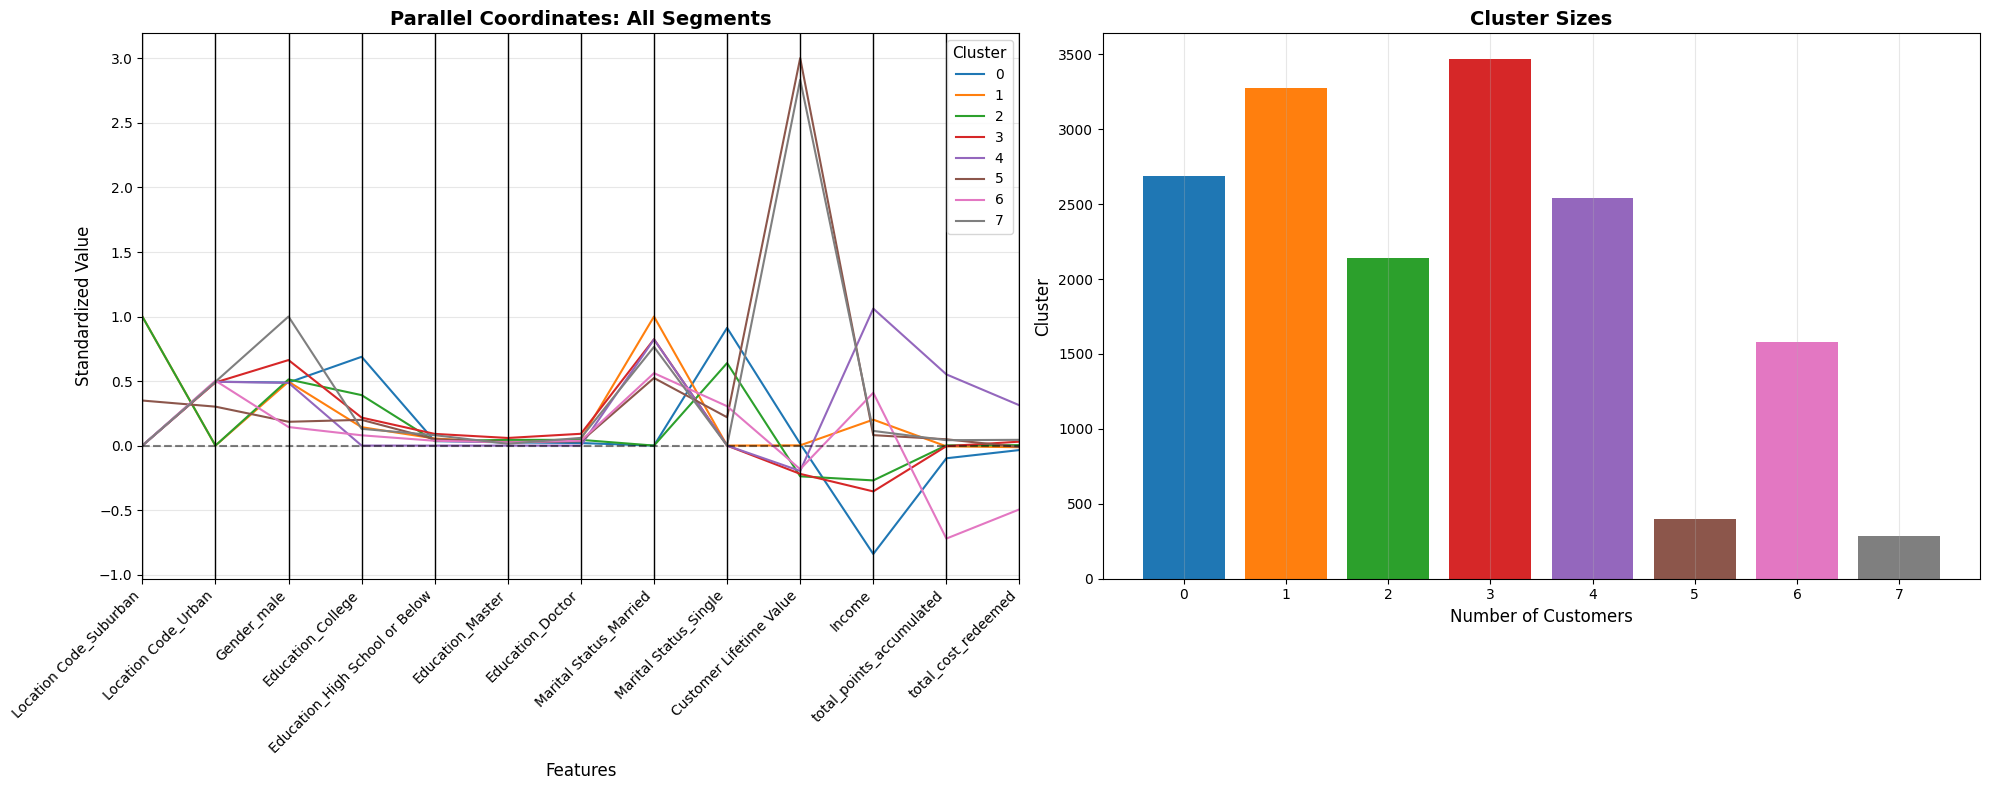

In [76]:
# Get centroids for ALL segments
all_segments = sorted(customers['merged_labels'].unique())
df_all_centroids = customers.groupby('merged_labels')[metric_features].mean()

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# LEFT PLOT: Parallel coordinates for all clusters
plt.sca(ax1)
pd.plotting.parallel_coordinates(
    df_all_centroids.reset_index(),
    'merged_labels',
    color=sns.color_palette('tab10', n_colors=len(all_segments)),
    ax=ax1
)
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.set_title('Parallel Coordinates: All Segments', fontsize=14, fontweight='bold')
ax1.set_ylabel('Standardized Value', fontsize=12)
ax1.set_xlabel('Features', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.legend(title='Cluster', loc='best', title_fontsize=11)
ax1.grid(True, alpha=0.3)

# RIGHT PLOT: Cluster sizes (ordered by cluster number)
cluster_sizes = customers['merged_labels'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(all_segments))

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

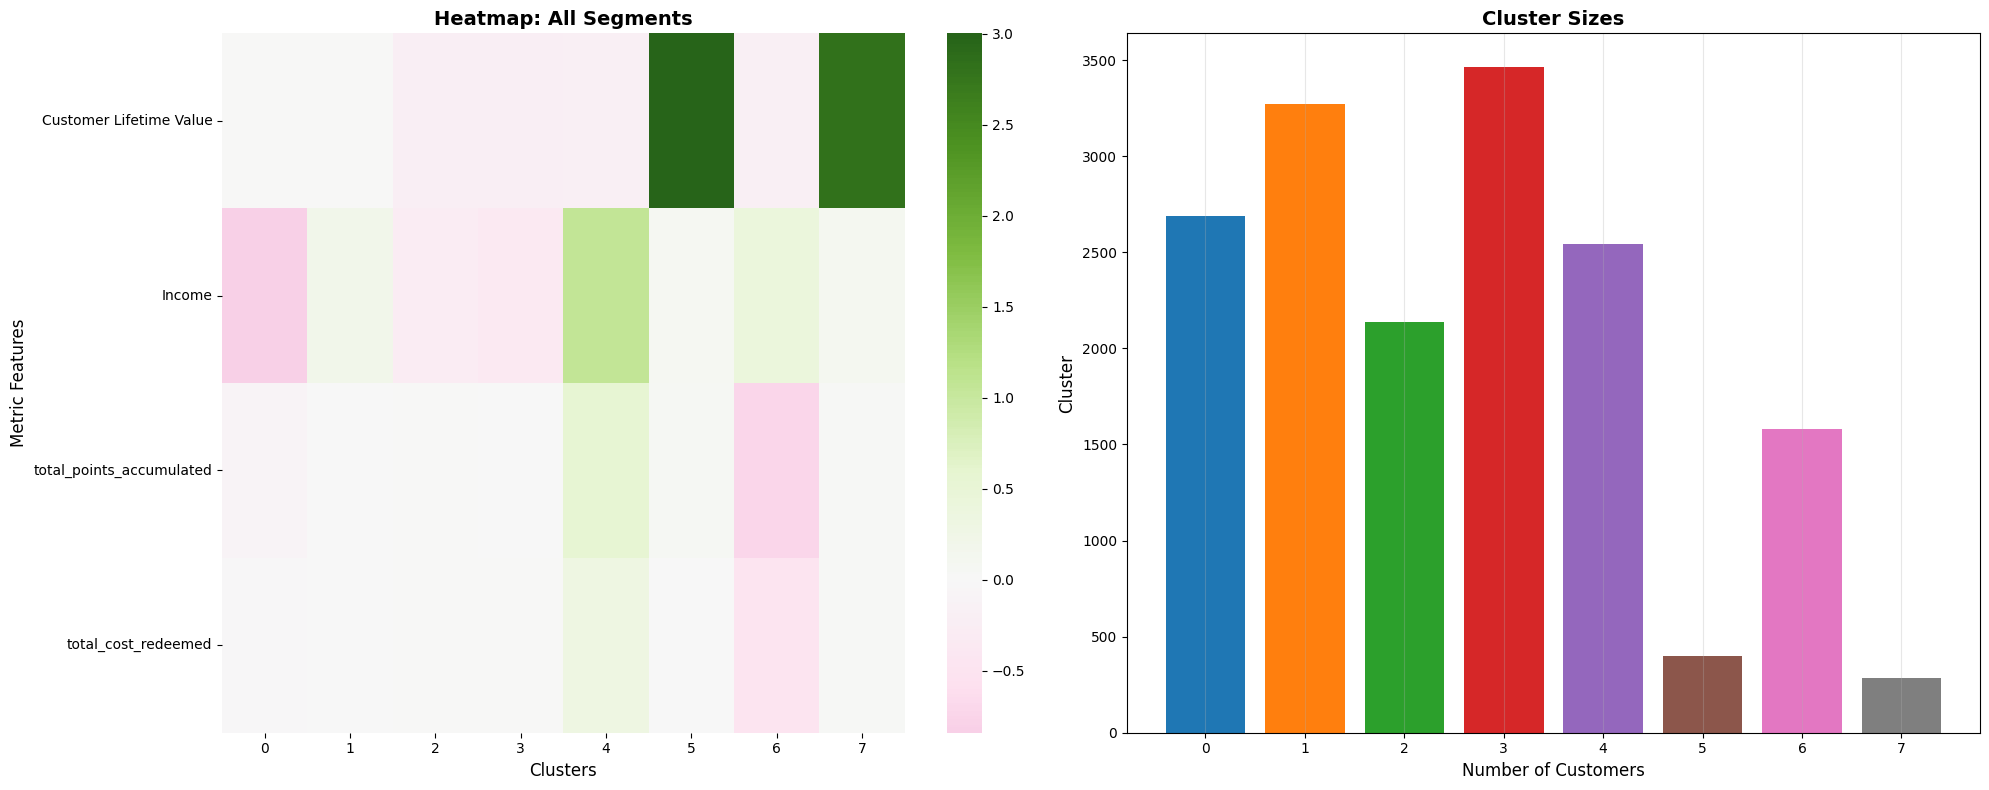

In [77]:
# ===========================================================
# Plot other type of visualization to profile the value_based features
# ===========================================================

all_segments = sorted(customers['merged_labels'].unique())
df_all_centroids = customers.groupby('merged_labels')[value_based_features].mean().T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    df_all_centroids,
    cmap='PiYG',
    ax=ax1,
    center=0
)

ax1.set_title('Heatmap: All Segments', fontsize=14, fontweight='bold')
ax1.set_ylabel('Metric Features', fontsize=12)
ax1.set_xlabel('Clusters', fontsize=12)
ax1.grid(False)


cluster_sizes = customers['merged_labels'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(all_segments))

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

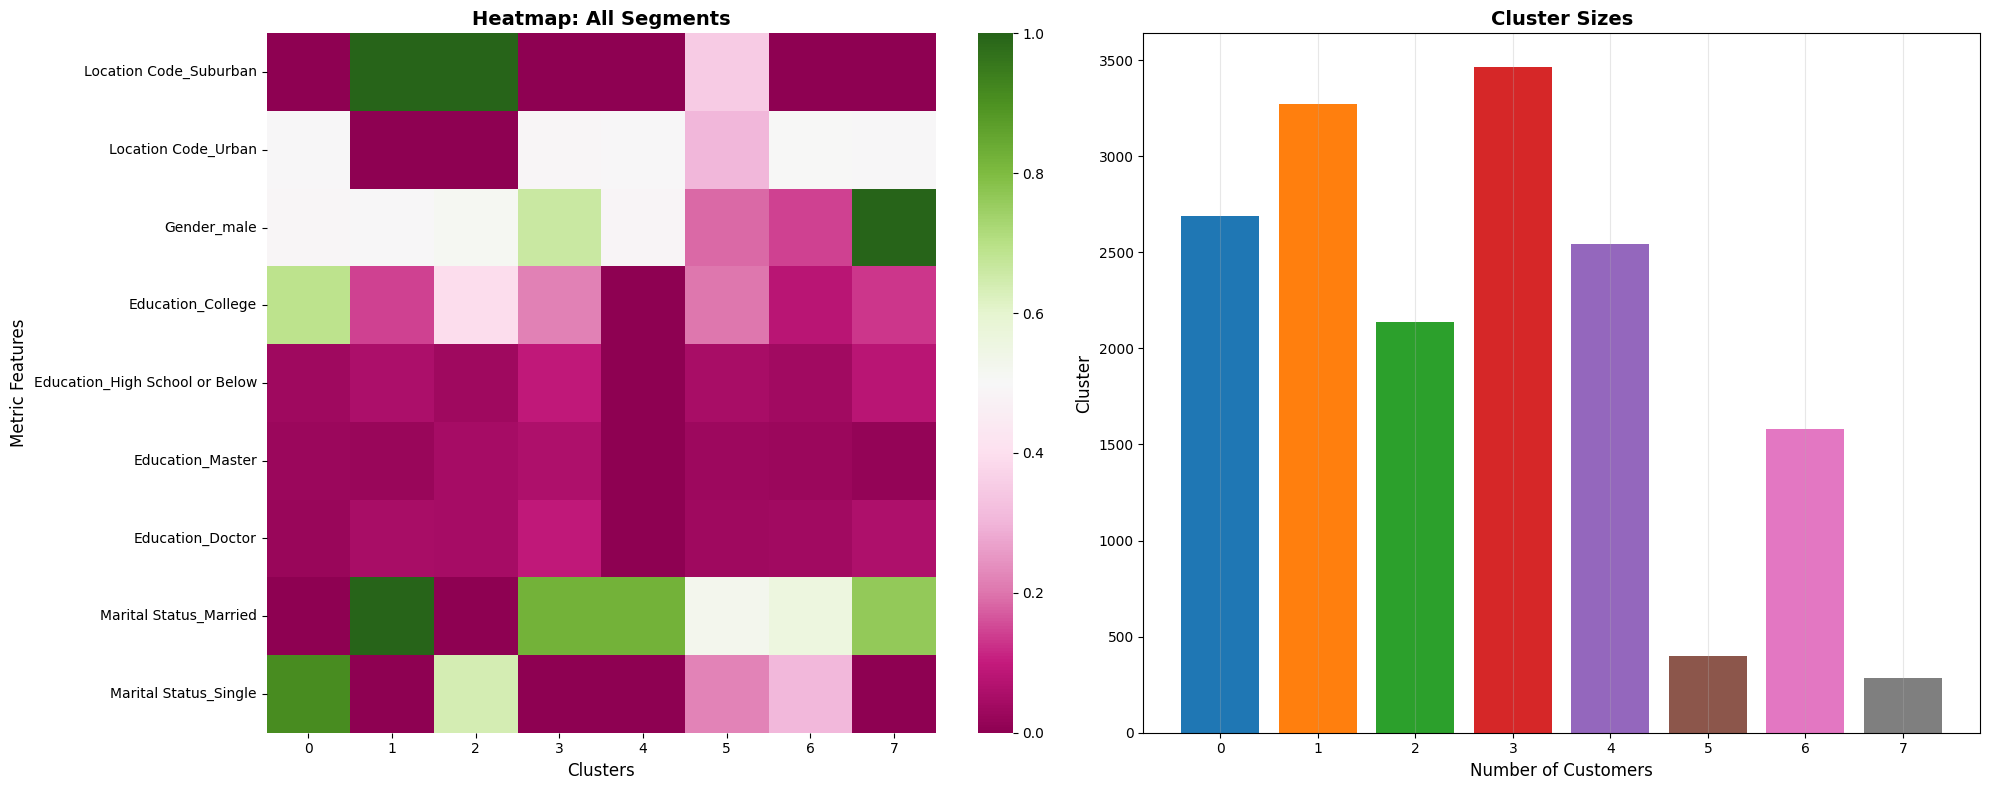

In [78]:
# ===========================================================
# Plot other type of visualization to profile the demographic features
# ===========================================================

all_segments = sorted(customers['merged_labels'].unique())
df_all_centroids = customers.groupby('merged_labels')[demographic_features].mean().T
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    df_all_centroids,
    cmap='PiYG',
    ax=ax1,
    center=0.5
)

ax1.set_title('Heatmap: All Segments', fontsize=14, fontweight='bold')
ax1.set_ylabel('Metric Features', fontsize=12)
ax1.set_xlabel('Clusters', fontsize=12)
ax1.grid(False)


cluster_sizes = customers['merged_labels'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(all_segments))

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Non metric features 

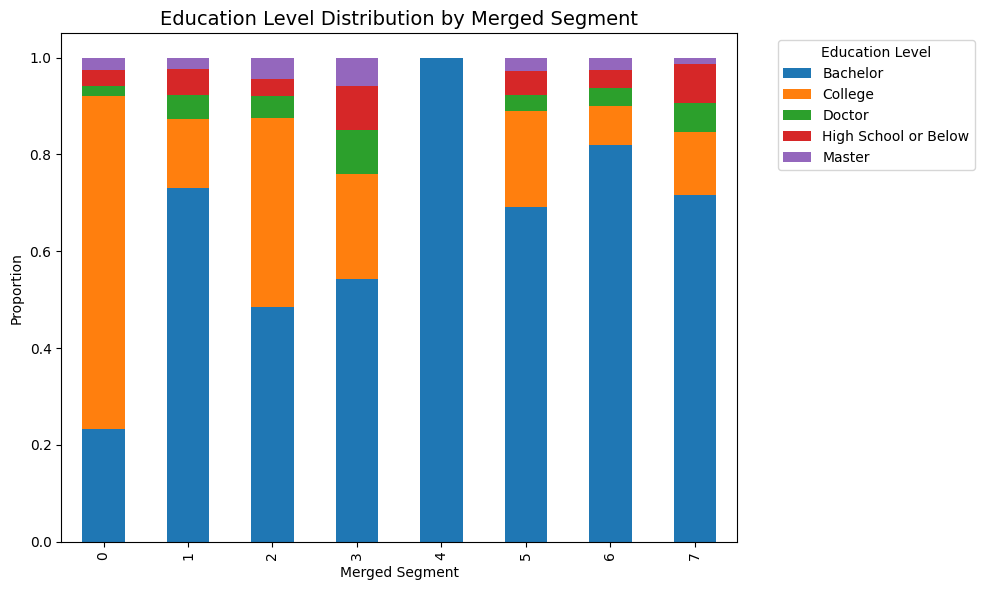

In [79]:
# ===========================================================
# Improve the profiling visualization for education across segments
# ===========================================================


pd.crosstab(customers['merged_labels'], customers['Education'], normalize='index').plot.bar(
    stacked=True,
    figsize=(10, 6)
)
plt.title("Education Level Distribution by Merged Segment", fontsize=14)
plt.xlabel("Merged Segment")
plt.ylabel("Proportion")
plt.legend(title="Education Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Feature Importances 

### Using $R^2$

In [80]:
def get_ss_variables(df):
    """Get the SS for each variable
    """
    ss_vars = df.var() * (df.count() - 1)
    return ss_vars

def r2_variables(df, labels):
    """Get the R² for each variable
    """
    sst_vars = get_ss_variables(df)
    ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))
    return 1 - ssw_vars/sst_vars

In [81]:
r2_feats = r2_variables(customers[metric_features + ['merged_labels']], 'merged_labels').drop('merged_labels')
r2_feats

Location Code_Suburban            0.975168
Location Code_Urban               0.242992
Gender_male                       0.098861
Education_College                 0.261450
Education_High School or Below    0.018673
Education_Master                  0.012435
Education_Doctor                  0.021344
Marital Status_Married            0.645148
Marital Status_Single             0.653993
Customer Lifetime Value           0.387424
Income                            0.351584
total_points_accumulated          0.099052
total_cost_redeemed               0.039158
dtype: float64

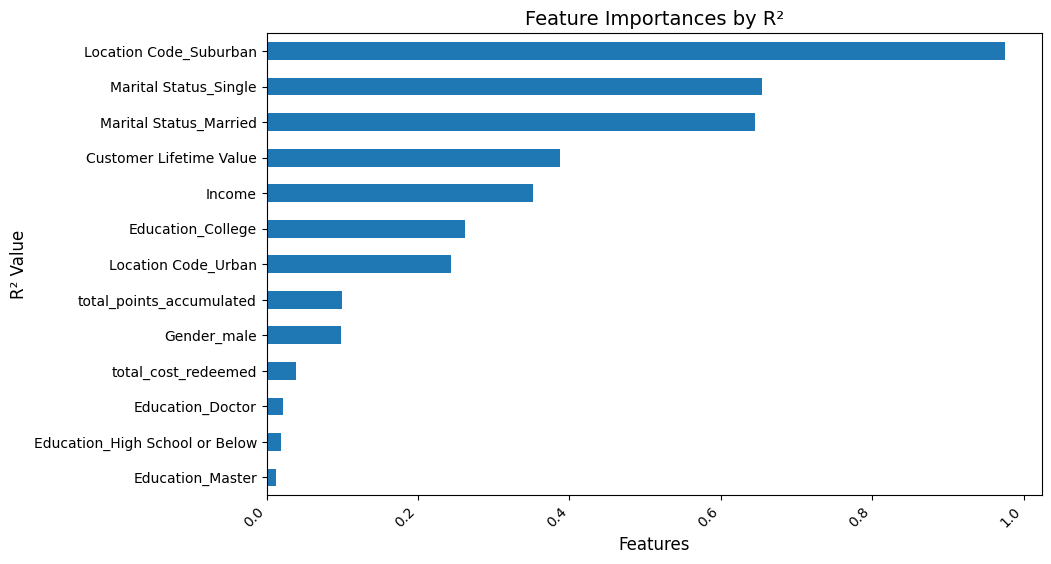

In [82]:
r2_feats.sort_values().plot.barh(figsize=(10,6))
plt.title("Feature Importances by R²", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("R² Value", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.show()